# Tea Leaf Disease Detection - Kaggle version

Trains and compares **YOLO11, YOLO12 and YOLO26**, picks the best one, and
produces every figure needed for the thesis.

## Set this up first, in the panel on the right

| Setting | Value |
|---|---|
| **Accelerator** | GPU **T4 x2** (do not pick P100, see note below) |
| **Internet** | On, needed for pip and for the Roboflow download |
| **Persistence** | Files only, or Variables and files |

> **Choose T4, not P100.** The P100 is an older card (sm_60) that recent
> PyTorch builds no longer support. If a run reports that the GPU is not
> compatible, switch the accelerator to T4 and start again.

**Add the Roboflow key as a secret:** Add-ons, then Secrets, then add
`ROBOFLOW_API_KEY`. Keeping the key out of the notebook means it stays private
even if the notebook is shared.

## Quota, and how the work is saved

Kaggle gives about 30 GPU hours a week and a single session runs for up to
about nine hours. That is more than a free Colab session, but a session can
still end before all three models finish, so every result is written to
`/kaggle/working` as soon as it is produced.

**To carry on in a later session:**

1. Press **Save Version** so that the contents of `/kaggle/working` are kept.
2. Open the notebook again and attach that saved output under **Add Input**.
3. Run the cells from the top. The training cell restores what was already
   finished, skips those models, and continues with the rest.


## 1. Check GPU

In [5]:
!nvidia-smi

Sun Sep 13 06:20:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependencies
`ultralytics` (YOLOv12), `roboflow` (dataset), and `onnx`/`onnxslim` (export).

In [6]:
# ===== Install (without breaking the GPU support that Kaggle ships) =====
# IMPORTANT: do not upgrade torch here.
# "pip install -U ultralytics" pulls a newer torch that has dropped support
# for older GPUs such as the P100 (compute capability sm_60). Kaggle already
# has a torch build that matches whichever GPU it gives you, so ultralytics is
# installed with --no-deps and the rest of its requirements are already present.

!pip install -q --no-deps ultralytics ultralytics-thop
!pip install -q py-cpuinfo          # small helper ultralytics imports
!pip install -q roboflow onnx onnxslim onnxruntime

import torch, ultralytics
print("ultralytics:", ultralytics.__version__)
print("torch      :", torch.__version__)

if not torch.cuda.is_available():
    print("NO GPU. Set Accelerator to GPU in the panel on the right.")
else:
    name = torch.cuda.get_device_name(0)
    cap  = torch.cuda.get_device_capability(0)
    sm   = cap[0] * 10 + cap[1]
    arch = torch.cuda.get_arch_list()
    print("device     :", name, " compute capability sm_" + str(sm))
    print("torch built for:", arch)
    if ("sm_" + str(sm)) not in arch:
        print("")
        print("*" * 66)
        print("This GPU is NOT supported by the installed torch build.")
        print("Training will fail or fall back to the CPU.")
        print("")
        print("Fix: in the panel on the right, set Accelerator to GPU T4 x2")
        print("     (T4 is sm_75 and is supported), then Factory reset and")
        print("     run this notebook again from the top.")
        print("*" * 66)
    else:
        print("GPU is supported, good to go.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 5.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.0/239.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 76.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.4 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
ultralytics: 8.4.150
torch      : 2.10.0+cu128
device     : Tesla T4  compute capability sm_75
torch built for: ['sm_70', 's

### 2.1 Where the results are stored

Everything is written to `/kaggle/working`, which is kept when a version is
saved. If an earlier session was saved and attached as an input dataset, its
contents are copied back in here, so a model that already finished is not
trained a second time.


In [7]:
# ===== Persistent storage on Kaggle =====
import os, json, glob, shutil

WORK     = "/kaggle/working"
PERSIST  = os.path.join(WORK, "tea_thesis")
RUNS_DIR = os.path.join(PERSIST, "runs")
STATE    = os.path.join(PERSIST, "runs_state.json")
FIG_DIR  = os.path.join(PERSIST, "thesis_figures")
for d in (PERSIST, RUNS_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# ---- restore an earlier session, if one is attached as an input -----------
# Attach the saved output of the previous run under "Add Input". Any input
# folder containing a runs_state.json is treated as an earlier session.
restored = False
for cand in sorted(glob.glob("/kaggle/input/*")):
    prev = os.path.join(cand, "tea_thesis")
    if os.path.exists(os.path.join(prev, "runs_state.json")):
        shutil.copytree(prev, PERSIST, dirs_exist_ok=True)
        print("restored an earlier session from", cand)
        restored = True
        break
if not restored:
    print("no earlier session attached, starting fresh")

print("PERSIST:", PERSIST)
if os.path.exists(STATE):
    print("already finished:", list(json.load(open(STATE))))


no earlier session attached, starting fresh
PERSIST: /kaggle/working/tea_thesis


### 2.2 Copying to Google Drive (optional)

Kaggle cannot mount Google Drive the way Colab does, so this step needs a
little setup and is switched off by default. Saving a version and downloading
the output from the Output tab is simpler and is usually enough.

To use it: create an rclone config for your Drive on your own computer, open
`rclone.conf`, copy its text, and store it as a Kaggle secret named
`RCLONE_CONF`. Then set `USE_GDRIVE = True` and call `push_to_drive()` after
training.


In [4]:
# ===== Optional: copy the results to Google Drive with rclone =====
USE_GDRIVE  = False              # set True once the RCLONE_CONF secret exists
GDRIVE_DEST = "gdrive:tea_thesis"

def push_to_drive():
    if not USE_GDRIVE:
        print("Google Drive copying is switched off")
        return
    try:
        from kaggle_secrets import UserSecretsClient
        conf = UserSecretsClient().get_secret("RCLONE_CONF")
    except Exception as e:
        print("RCLONE_CONF secret not found:", e)
        return
    os.makedirs("/root/.config/rclone", exist_ok=True)
    with open("/root/.config/rclone/rclone.conf", "w") as f:
        f.write(conf)
    os.system("curl -s https://rclone.org/install.sh | bash > /dev/null 2>&1")
    os.system('rclone copy "%s" "%s" --progress' % (PERSIST, GDRIVE_DEST))
    print("copied to", GDRIVE_DEST)

print("call push_to_drive() after training if USE_GDRIVE is True")


call push_to_drive() after training if USE_GDRIVE is True


## 3. Download the dataset from Roboflow
This is your snippet. It downloads the dataset in YOLOv12 format and prints its location.

In [8]:
from roboflow import Roboflow
import os

# The key is read from Kaggle Secrets so it never lives in the notebook.
# Add-ons -> Secrets -> ROBOFLOW_API_KEY
try:
    from kaggle_secrets import UserSecretsClient
    ROBOFLOW_API_KEY = UserSecretsClient().get_secret("ROBOFLOW_API_KEY")
except Exception:
    ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "")
if not ROBOFLOW_API_KEY:
    raise SystemExit("Set ROBOFLOW_API_KEY in Kaggle Secrets or the environment.")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("sanojs-workspace-uhhjv").project("my-first-project-un4mw")

# Use whichever version number is actually generated in your Roboflow dashboard
dataset = project.version(3).download("yolov12", location="/kaggle/working/dataset")

data_yaml = os.path.join(dataset.location, "data.yaml")
print("dataset  :", dataset.location)
print("data.yaml:", data_yaml, os.path.exists(data_yaml))

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/dataset in yolov12:: 100%|██████████| 13136/13136 [00:01<00:00, 6673.66it/s] 


dataset  : /kaggle/working/dataset
data.yaml: /kaggle/working/dataset/data.yaml True


## 4. Inspect the dataset
Print the class names and counts. **⚠️ Note the class names printed below — you'll paste them into `app.js` on the website.**

In [9]:
# ===== Inspect the dataset =====
import yaml, os, glob

cfg = yaml.safe_load(open(data_yaml))
names = cfg["names"]
CLASS_NAMES = [names[k] for k in sorted(names)] if isinstance(names, dict) else list(names)
print("number of classes:", len(CLASS_NAMES))
print("classes          :", CLASS_NAMES)

for split in ("train", "valid", "test"):
    d = os.path.join(dataset.location, split, "images")
    if os.path.isdir(d):
        print("%-6s %d images" % (split, len(glob.glob(os.path.join(d, "*")))))


number of classes: 2
classes          : ['Nondefect', 'defect']
train  6522 images
valid  44 images


In [10]:
# ===== Re-split dataset into 80/15/5 (train/valid/test) =====
import os, glob, shutil, random, yaml

random.seed(42)

SRC = dataset.location                     # original Roboflow-downloaded dataset
DST = "/kaggle/working/dataset_split"      # new re-split dataset

# 1. Collect every image (+ matching label, if any) from all existing splits
image_exts = (".jpg", ".jpeg", ".png", ".bmp")
all_items = []
for split in ("train", "valid", "test"):
    img_dir = os.path.join(SRC, split, "images")
    lbl_dir = os.path.join(SRC, split, "labels")
    if not os.path.isdir(img_dir):
        continue
    for img_path in glob.glob(os.path.join(img_dir, "*")):
        if img_path.lower().endswith(image_exts):
            base = os.path.splitext(os.path.basename(img_path))[0]
            lbl_path = os.path.join(lbl_dir, base + ".txt")
            all_items.append((img_path, lbl_path if os.path.exists(lbl_path) else None))

print("total images pooled:", len(all_items))

# 2. Shuffle and split 80/15/5
random.shuffle(all_items)
n = len(all_items)
n_train = int(n * 0.80)
n_valid = int(n * 0.15)
n_test  = n - n_train - n_valid   # remainder, avoids rounding loss

splits = {
    "train": all_items[:n_train],
    "valid": all_items[n_train:n_train + n_valid],
    "test":  all_items[n_train + n_valid:],
}
for name, items in splits.items():
    print(f"{name:6s} {len(items)} images")

# 3. Copy into new split folders (originals untouched)
for split_name, items in splits.items():
    img_out = os.path.join(DST, split_name, "images")
    lbl_out = os.path.join(DST, split_name, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    for img_path, lbl_path in items:
        shutil.copy2(img_path, img_out)
        if lbl_path:
            shutil.copy2(lbl_path, lbl_out)

# 4. Write a new data.yaml pointing at the re-split dataset
new_yaml_path = os.path.join(DST, "data.yaml")
new_cfg = {
    "train": os.path.join(DST, "train", "images"),
    "val":   os.path.join(DST, "valid", "images"),
    "test":  os.path.join(DST, "test", "images"),
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
with open(new_yaml_path, "w") as f:
    yaml.safe_dump(new_cfg, f)

print("\nnew data.yaml written to:", new_yaml_path)

total images pooled: 6566
train  5252 images
valid  984 images
test   330 images

new data.yaml written to: /kaggle/working/dataset_split/data.yaml


## 5. Train and compare three detectors

Ultralytics does not recommend **YOLOv12** for production. Its attention-centred
backbone can be unstable during training and uses more memory, which can cost
accuracy and makes runs harder to reproduce. The alternatives are:

| Model | Why it is a candidate |
|---|---|
| **YOLO11s** | Proven and stable, the safe baseline |
| **YOLO12s** | Attention-centred, strong on paper but less stable |
| **YOLO26s** | Newest. NMS-free, adds ProgLoss and STAL, which improve small-object accuracy. Relevant here because leaf defects are small features. |

All three share the same API, so they can be swapped directly. The cells below
train all three under identical settings, measure accuracy and speed, plot the
comparison, and pick the best one. Everything after this section uses the winner.

> **Note on YOLO26:** it is NMS-free (end-to-end), so its raw output differs from
> the other two. That matters if the model is later decoded by hand. It is handled
> automatically here, but it deserves a sentence in the thesis.


### 5.1 Settings for the comparison
Every setting is identical across the three models, otherwise the comparison is
not fair. Lower `EPOCHS` if Colab time is short, because three trainings run one
after another.

In [13]:
# ===== Comparison settings =====
# Nano models train about three times faster than small ones. On a free Colab
# session nano is the safer choice, and the comparison between the three
# architectures stays just as valid.
SIZE = "s"                 # "n" = nano (fast), "s" = small (slower, more accurate)

MODELS = {
    "YOLO11" + SIZE: "yolo11" + SIZE + ".pt",   # proven and stable
    "YOLO12" + SIZE: "yolo12" + SIZE + ".pt",   # attention-centred
    "YOLO26" + SIZE: "yolo26" + SIZE + ".pt",   # newest, NMS-free, good on small objects
}

# ---- these decide how long training takes ---------------------------------
EPOCHS   = 50      # lower this first if time is short
IMGSZ    = 640     # 512 trains roughly 1.6 times faster; must match the device later
BATCH    = -1     # -1 lets Ultralytics pick the largest batch that fits
PATIENCE = 8      # stop a model that has stopped improving
SEED     = 0       # same seed for all three, so the comparison is fair

# ---- these speed things up without changing the result --------------------
CACHE   = "ram"    # keep decoded images in memory, a large win on small datasets
WORKERS = 2        # 2 is usually faster than the default on Colab
AMP     = True     # half precision, on by default, stated here for clarity

# ---- how the winner is chosen ---------------------------------------------
W_ACC = 0.7                # weight on accuracy, the rest (0.3) goes to speed
LATENCY_BUDGET_MS = None   # e.g. 150 to reject anything slower, None = no limit

import ultralytics, torch
print("ultralytics:", ultralytics.__version__)
print("torch      :", torch.__version__, "| GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device     :", torch.cuda.get_device_name(0))

print("\nPlanned: %d models x %d epochs = %d epochs in total."
      % (len(MODELS), EPOCHS, EPOCHS * len(MODELS)))
print("If the session is short, lower EPOCHS or IMGSZ before starting.")


ultralytics: 8.4.150
torch      : 2.10.0+cu128 | GPU: True
device     : Tesla T4

Planned: 2 models x 50 epochs = 100 epochs in total.
If the session is short, lower EPOCHS or IMGSZ before starting.


### 5.2 Train all three
This is the long cell. Each model trains in turn on the same data with the same
settings. A failure in one model does not stop the others.

In [17]:
# ===== Comparison settings (Kaggle, T4 x2) =====
import os, json, torch, ultralytics

# ---- dataset ---------------------------------------------------------------
DATA = new_yaml_path                       # /kaggle/working/dataset_split/data.yaml

RUNS_DIR = "/kaggle/working/runs"
STATE    = "/kaggle/working/train_state.json"
os.makedirs(RUNS_DIR, exist_ok=True)

# ---- GPU setup -------------------------------------------------------------
NGPU   = torch.cuda.device_count()
DEVICE = list(range(NGPU)) if NGPU > 1 else 0      # [0, 1] -> DDP across both T4s

# ---- which models, and the batch each one gets -----------------------------
# BATCH is the TOTAL batch; Ultralytics splits it across the GPUs.
# YOLOv12 is attention-based (A2C2f/AAttn) and is the only one that failed at 64,
# so it gets 32 (= 16 per T4). Everything else is identical across the three.
SIZE = "s"
MODELS = {
    "YOLO11" + SIZE: {"ckpt": "yolo11" + SIZE + ".pt", "batch": 64},
    "YOLO12" + SIZE: {"ckpt": "yolo12" + SIZE + ".pt", "batch": 32},
    "YOLO26" + SIZE: {"ckpt": "yolo26" + SIZE + ".pt", "batch": 64},
}

# ---- these decide how long training takes ----------------------------------
EPOCHS   = 50
IMGSZ    = 640
PATIENCE = 8
SEED     = 0

# ---- speed -----------------------------------------------------------------
# cache="disk" writes decoded .npy files once and both ranks read the same
# files. cache="ram" would build a separate copy per rank and risk an OOM on
# Kaggle's 30 GiB; cache=False re-decodes every JPEG every epoch.
CACHE   = "disk"
WORKERS = 2          # per rank; 2 x 2 ranks = 4, matching Kaggle's vCPU count
AMP     = True

# ---- how the winner is chosen ----------------------------------------------
W_ACC = 0.7
LATENCY_BUDGET_MS = None

print("ultralytics:", ultralytics.__version__)
print("torch      :", torch.__version__, "| CUDA:", torch.cuda.is_available())
for i in range(NGPU):
    p = torch.cuda.get_device_properties(i)
    print("  GPU %d: %s, %.1f GiB" % (i, p.name, p.total_memory / 1024**3))

print("\ndata   :", DATA)
print("device :", DEVICE, "(%d GPU%s)" % (NGPU, "" if NGPU == 1 else "s"))
print("cache  :", CACHE, "| workers:", WORKERS, "per rank")
for n, c in MODELS.items():
    per = c["batch"] // max(1, NGPU)
    print("  %-9s batch %3d  (%d per GPU)" % (n, c["batch"], per))
print("\nPlanned: %d models x %d epochs = %d epochs total."
      % (len(MODELS), EPOCHS, EPOCHS * len(MODELS)))
if NGPU < 2:
    print("\nOnly one GPU visible. Set the accelerator to 'GPU T4 x2' and restart.")

ultralytics: 8.4.150
torch      : 2.10.0+cu128 | CUDA: True
  GPU 0: Tesla T4, 14.6 GiB
  GPU 1: Tesla T4, 14.6 GiB

data   : /kaggle/working/dataset_split/data.yaml
device : [0, 1] (2 GPUs)
cache  : disk | workers: 2 per rank
  YOLO11s   batch  64  (32 per GPU)
  YOLO12s   batch  32  (16 per GPU)
  YOLO26s   batch  64  (32 per GPU)

Planned: 3 models x 50 epochs = 150 epochs total.


In [18]:
# ===== Train the three candidates, safe against a runtime reset =====
from ultralytics import YOLO
import time, traceback, os, json

RUNS = json.load(open(STATE)) if os.path.exists(STATE) else {}


def save_state():
    with open(STATE, "w") as f:
        json.dump(RUNS, f, indent=1)


def train_one(ckpt, name, device, batch):
    m = YOLO(ckpt)
    m.train(data=DATA, epochs=EPOCHS, imgsz=IMGSZ, batch=batch,
            patience=PATIENCE, seed=SEED, cache=CACHE, workers=WORKERS,
            amp=AMP, device=device, project=RUNS_DIR, name=name,
            exist_ok=True, plots=True, verbose=False)
    return m


for name, cfg in MODELS.items():
    ckpt, batch = cfg["ckpt"], cfg["batch"]

    if name in RUNS and os.path.exists(RUNS[name].get("best_pt", "")):
        print("SKIP %s, already trained: %s" % (name, RUNS[name]["best_pt"]))
        continue

    run_dir = os.path.join(RUNS_DIR, name)
    last_pt = os.path.join(run_dir, "weights", "last.pt")
    resuming = os.path.exists(last_pt)

    print("=" * 62)
    print(("RESUMING " if resuming else "TRAINING ") + name)
    print("=" * 62)

    # Try both GPUs first, then both GPUs at half batch, then one GPU.
    # Both-GPU attempts come first so a model only drops to a single card
    # if multi-GPU genuinely cannot run it.
    ladder = [(DEVICE, batch)]
    if isinstance(DEVICE, list):
        ladder += [(DEVICE, max(2 * NGPU, batch // 2)), (0, batch // 2)]

    m, device_used, batch_used, last_err = None, None, None, None
    try:
        t0 = time.time()
        if resuming:
            m = YOLO(last_pt)
            m.train(resume=True)          # settings come from the checkpoint
            device_used, batch_used = "resumed", "resumed"
        else:
            for dev, bs in ladder:
                try:
                    print("-> attempt: device=%s batch=%d" % (dev, bs))
                    m = train_one(ckpt, name, dev, bs)
                    device_used, batch_used = dev, bs
                    break
                except Exception as e:
                    last_err = e
                    print("   attempt failed: %s" % str(e)[:300])
                    torch.cuda.empty_cache()
            if m is None:
                raise last_err

        best = getattr(getattr(m, "trainer", None), "best", None)
        best = str(best) if best else os.path.join(run_dir, "weights", "best.pt")

        RUNS[name] = {
            "checkpoint": ckpt,
            "best_pt":    best,
            "run_dir":    run_dir,
            "device":     str(device_used),
            "batch":      batch_used,
            "imgsz":      IMGSZ,
            "epochs":     EPOCHS,
            "train_min":  (time.time() - t0) / 60.0,
        }
        save_state()
        print("%s done in %.1f min -> %s"
              % (name, RUNS[name]["train_min"], best))

    except KeyboardInterrupt:
        print("\nInterrupted. Progress is saved in", last_pt)
        raise
    except Exception as e:
        print("%s FAILED: %s" % (name, e))
        traceback.print_exc()

print("\nfinished models:", list(RUNS))

# Report the config actually used, per model
print("\n%-10s %-10s %-7s %s" % ("model", "device", "batch", "minutes"))
for n, r in RUNS.items():
    print("%-10s %-10s %-7s %.1f" % (n, r["device"], r["batch"], r["train_min"]))

devs = {r["device"] for r in RUNS.values()}
if len(devs) > 1:
    print("\nWARNING: models ran on different device counts:", devs)
    print("Wall-clock times are not comparable. Use measured inference "
          "latency for the speed term instead of train_min.")

if not RUNS:
    raise RuntimeError("No model trained. Check DATA and the accelerator setting.")

TRAINING YOLO11s
-> attempt: device=[0, 1] batch=64
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_split/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      7.77G      1.311      1.337      1.405         13        640: 100% ━━━━━━━━━━━━ 83/83 2.0it/s 41.0s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.0s0.7ss
                   all        984       7080      0.316      0.498      0.288      0.137

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      7.77G      1.333       1.35      1.415         19        640: 100% ━━━━━━━━━━━━ 83/83 2.0it/s 41.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3it/s 6.4s0.9ss
                   all        984       7080      0.333      0.404      0.285      0.154

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      7.73G      1.304        1.3      1.398         37        640: 10

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      6.14G      1.389      1.434      1.531         17        640: 100% ━━━━━━━━━━━━ 165/165 2.6it/s 1:040.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.6it/s 6.1s0.4s
                   all        984       7080      0.499      0.594      0.539      0.333

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      6.09G      1.336      1.354      1.493         18        640: 100% ━━━━━━━━━━━━ 165/165 2.6it/s 1:030.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.5it/s 6.4s0.4s
                   all        984       7080      0.545      0.491      0.481      0.261

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      6.15G      1.316      1.323      1.474         44        6

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       2/50      9.28G      1.349      1.538    0.01418         13        640: 100% ━━━━━━━━━━━━ 83/83 1.7it/s 49.5s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6it/s 5.1s0.7ss
                   all        984       7080       0.62      0.552       0.59      0.354

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       3/50      9.27G       1.37      1.473    0.01438         19        640: 100% ━━━━━━━━━━━━ 83/83 1.7it/s 48.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5it/s 5.3s0.7ss
                   all        984       7080      0.626      0.549      0.588      0.358

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size
       4/50      9.28G      1.363      1.414    0.01421         37        640: 10

### 5.3 Measure accuracy and speed
Accuracy comes from the held-out split. Speed is measured twice: on the GPU of
this notebook, and through ONNX on the CPU, which stands in roughly for the
Raspberry Pi. The CPU figure is the one that matters for the deployment.

In [20]:
# ===== Accuracy and latency for each model =====
import os, json, glob, time
import numpy as np, pandas as pd, cv2
from pathlib import Path
from ultralytics import YOLO

# ---- pick the runs back up if the kernel restarted --------------------------
if not globals().get("RUNS"):
    RUNS = json.load(open(STATE)) if os.path.exists(STATE) else {}
    print("loaded from the state file:", list(RUNS))
if not RUNS:
    raise RuntimeError("No trained runs found. Train first, or check STATE.")

# ---- output directory (Path, so the / operator works) -----------------------
FIG_DIR = Path(globals().get("FIG_DIR", "/kaggle/working/figures"))
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("figures ->", FIG_DIR)

# ---- evaluate on the RE-SPLIT dataset, not the original Roboflow download ----
# DATA points at /kaggle/working/dataset_split/data.yaml. The original download
# had no test folder and its 44 valid images were pooled into training when the
# 80/15/5 split was built, so evaluating there would score partly on train data.
DATA_ROOT = os.path.dirname(DATA)

def _split_dir(s):
    p = os.path.join(DATA_ROOT, s)
    return p if os.path.isdir(os.path.join(p, "images")) else None

EVAL_SPLIT = "test" if _split_dir("test") else "val"
_vd = _split_dir("test") or _split_dir("valid")
if _vd is None:
    raise RuntimeError("No test or valid images found under " + DATA_ROOT)

_imgs = sorted(glob.glob(os.path.join(_vd, "images", "*")))
if not _imgs:
    raise RuntimeError("No image files in " + os.path.join(_vd, "images"))
SAMPLE_IMG = _imgs[0]
print("evaluating on split:", EVAL_SPLIT, "->", _vd, "(%d images)" % len(_imgs))


def bench(fn, n=30, warm=5):
    """Median-based timing; median is robust to the occasional Kaggle stall."""
    for _ in range(warm):
        fn()
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        ts.append((time.perf_counter() - t0) * 1000)
    return float(np.median(ts)), float(np.std(ts))


try:
    import onnxruntime as ort
except ImportError:
    ort = None
    print("onnxruntime missing; CPU latency will be skipped")


def letterbox(im, new=640, color=(114, 114, 114)):
    h, w = im.shape[:2]
    r = min(new / h, new / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    out = np.full((new, new, 3), color, np.uint8)
    top, left = (new - nh) // 2, (new - nw) // 2
    out[top:top + nh, left:left + nw] = cv2.resize(im, (nw, nh))
    return out


_raw = cv2.imread(SAMPLE_IMG)
if _raw is None:
    raise RuntimeError("cv2 could not read " + SAMPLE_IMG)
_img = cv2.cvtColor(_raw, cv2.COLOR_BGR2RGB)
BLOB = (letterbox(_img, IMGSZ).astype(np.float32) / 255.0).transpose(2, 0, 1)[None]
BLOB = np.ascontiguousarray(BLOB)

rows = []
for name, info in RUNS.items():
    best = info.get("best_pt", "")
    if not os.path.exists(best):
        print("SKIP %s, best.pt missing: %s" % (name, best))
        continue

    print("-" * 50)
    print("measuring", name)
    mdl = YOLO(best)

    # ---- accuracy on the held-out split ------------------------------------
    res = mdl.val(data=DATA, split=EVAL_SPLIT, imgsz=IMGSZ,
                  device=0, verbose=False, plots=False)

    n_params = sum(p.numel() for p in mdl.model.parameters())
    size_mb = os.path.getsize(best) / 1e6

    # ---- per-class mAP, matters when one class is rare ----------------------
    per_class = {}
    try:
        for ci in res.ap_class_index:
            per_class[CLASS_NAMES[ci]] = float(res.box.maps[ci])
    except Exception:
        pass

    # ---- GPU latency, batch 1, single GPU ----------------------------------
    gpu_ms, gpu_sd = bench(
        lambda: mdl.predict(SAMPLE_IMG, imgsz=IMGSZ, device=0, verbose=False))

    # ---- CPU latency via ONNX ----------------------------------------------
    cpu_ms, onnx_path = float("nan"), None
    try:
        onnx_path = str(mdl.export(format="onnx", opset=12, imgsz=IMGSZ,
                                   simplify=True, dynamic=False))
        if ort:
            sess = ort.InferenceSession(onnx_path,
                                        providers=["CPUExecutionProvider"])
            iname = sess.get_inputs()[0].name
            cpu_ms, _ = bench(lambda: sess.run(None, {iname: BLOB}), n=20, warm=3)
    except Exception as e:
        print("  ONNX export or benchmark failed for %s: %s" % (name, e))

    info["onnx"] = onnx_path
    rows.append({
        "model":        name,
        "params_M":     n_params / 1e6,
        "size_MB":      size_mb,
        "precision":    float(res.box.mp),
        "recall":       float(res.box.mr),
        "mAP50":        float(res.box.map50),
        "mAP50_95":     float(res.box.map),
        "gpu_ms":       gpu_ms,
        "gpu_fps":      1000.0 / gpu_ms if gpu_ms else float("nan"),
        "cpu_ms":       cpu_ms,
        "train_min":    info.get("train_min"),
        "train_batch":  info.get("batch"),
        "train_device": info.get("device"),
        "per_class":    per_class,
    })
    print("  mAP50-95=%.4f  mAP50=%.4f  gpu=%.1f ms  cpu=%.1f ms"
          % (rows[-1]["mAP50_95"], rows[-1]["mAP50"], gpu_ms, cpu_ms))

    del mdl
    try:
        import torch
        torch.cuda.empty_cache()
    except Exception:
        pass

if not rows:
    raise RuntimeError("Nothing measured. Check that best.pt files exist.")

# ---- save the state file so the onnx paths persist --------------------------
with open(STATE, "w") as f:
    json.dump(RUNS, f, indent=1)

# ---- table ------------------------------------------------------------------
cmp_df = pd.DataFrame(rows).set_index("model")
csv_path = FIG_DIR / "model_comparison.csv"
cmp_df.drop(columns=["per_class"]).to_csv(csv_path)
print()
print(cmp_df.drop(columns=["per_class"]).round(4).to_string())
print("\nsaved ->", csv_path)

# ---- per-class breakdown ----------------------------------------------------
if any(r["per_class"] for r in rows):
    print("\nper-class mAP50-95:")
    for r in rows:
        if r["per_class"]:
            print("  %-10s %s" % (r["model"], "  ".join(
                "%s %.3f" % (c, m) for c, m in r["per_class"].items())))

# ---- score and winner -------------------------------------------------------
best_acc = cmp_df["mAP50_95"].max()
best_lat = cmp_df["gpu_ms"].min()
cmp_df["acc_norm"] = cmp_df["mAP50_95"] / best_acc
cmp_df["speed_norm"] = best_lat / cmp_df["gpu_ms"]
cmp_df["score"] = W_ACC * cmp_df["acc_norm"] + (1 - W_ACC) * cmp_df["speed_norm"]

eligible = cmp_df
if LATENCY_BUDGET_MS is not None:
    ok = cmp_df[cmp_df["gpu_ms"] <= LATENCY_BUDGET_MS]
    if len(ok):
        eligible = ok
    else:
        print("\nNo model met LATENCY_BUDGET_MS = %s; scoring all." % LATENCY_BUDGET_MS)

winner = eligible["score"].idxmax()
print("\nWINNER: %s" % winner)
print("  mAP50-95 %.4f | %.1f ms (%.1f FPS) | %.2f M params"
      % (cmp_df.loc[winner, "mAP50_95"], cmp_df.loc[winner, "gpu_ms"],
         cmp_df.loc[winner, "gpu_fps"], cmp_df.loc[winner, "params_M"]))
print("  weights: %s" % RUNS[winner]["best_pt"])

with open(FIG_DIR / "comparison.json", "w") as f:
    json.dump({"winner": winner, "w_acc": W_ACC, "eval_split": EVAL_SPLIT,
               "latency_budget_ms": LATENCY_BUDGET_MS, "imgsz": IMGSZ,
               "rows": rows}, f, indent=2)

# ---- fairness note ----------------------------------------------------------
if cmp_df["train_batch"].nunique() > 1 or cmp_df["train_device"].nunique() > 1:
    print("\nNOTE: models trained with different settings (batch %s, device %s)."
          % (sorted(set(cmp_df["train_batch"].dropna())),
             sorted(set(cmp_df["train_device"].dropna()))))
    print("Accuracy gaps partly reflect that, not architecture alone.")

figures -> /kaggle/working/tea_thesis/thesis_figures
evaluating on split: test -> /kaggle/working/dataset_split/test (330 images)
--------------------------------------------------
measuring YOLO11s
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 62.7±25.0 MB/s, size: 81.5 KB)
val: Scanning /kaggle/working/dataset_split/test/labels... 330 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 744.2it/s 0.4s0.1s
val: New cache created: /kaggle/working/dataset_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.7it/s 4.5s0.2s
                   all        330       2314      0.774      0.758      0.836      0.669
Speed: 0.9ms preprocess, 9.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Ultralytics 8.4.150 🚀 Python-3.12.13

### 5.4 Comparison plots
These five figures belong in the thesis section where the choice of model is
justified.

In [24]:
# ===== Export models to ONNX for Raspberry Pi 5 (ARM64 CPU, 640, 16 GB RAM) =====
import os, json, glob, time, shutil, zipfile
import numpy as np, cv2
from pathlib import Path
from ultralytics import YOLO

EXPORT_DIR = Path("/kaggle/working/pi5_export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

PI_IMGSZ = 640          # must match what the Pi script uses
OPSET    = 13           # onnxruntime on ARM64 handles 13 comfortably
MAKE_INT8 = True        # static INT8 quantization, roughly 2x faster on ARM
N_CALIB   = 200         # calibration images for INT8

# Which models to export: all trained, or just the winner
EXPORT_MODELS = list(RUNS.keys())        # or e.g. [winner]

# ---- calibration / validation images from the held-out test split -----------
DATA_ROOT = os.path.dirname(DATA)
_test_dir = os.path.join(DATA_ROOT, "test", "images")
if not os.path.isdir(_test_dir):
    _test_dir = os.path.join(DATA_ROOT, "valid", "images")
calib_imgs = sorted(glob.glob(os.path.join(_test_dir, "*")))
print("calibration pool:", len(calib_imgs), "images from", _test_dir)


def letterbox(im, new=640, color=(114, 114, 114)):
    h, w = im.shape[:2]
    r = min(new / h, new / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    out = np.full((new, new, 3), color, np.uint8)
    top, left = (new - nh) // 2, (new - nw) // 2
    out[top:top + nh, left:left + nw] = cv2.resize(im, (nw, nh))
    return out


def preprocess(path, size=640):
    im = cv2.imread(path)
    if im is None:
        return None
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    blob = letterbox(im, size).astype(np.float32) / 255.0
    return np.ascontiguousarray(blob.transpose(2, 0, 1)[None])


# ---- ONNX Runtime ------------------------------------------------------------
try:
    import onnxruntime as ort
    from onnxruntime.quantization import (quantize_static, CalibrationDataReader,
                                          QuantFormat, QuantType)
    HAVE_ORT = True
except ImportError:
    HAVE_ORT = False
    MAKE_INT8 = False
    print("onnxruntime not available: skipping verification and INT8")


class ImgCalibReader(CalibrationDataReader):
    """Feeds real images to the quantizer so activation ranges are realistic."""
    def __init__(self, paths, input_name, size):
        self.paths = paths
        self.input_name = input_name
        self.size = size
        self.i = 0

    def get_next(self):
        while self.i < len(self.paths):
            blob = preprocess(self.paths[self.i], self.size)
            self.i += 1
            if blob is not None:
                return {self.input_name: blob}
        return None

    def rewind(self):
        self.i = 0


def bench_onnx(path, blob, n=20, warm=5, threads=4):
    """Rough CPU timing. Kaggle is x86 Xeon, the Pi 5 is Cortex-A76 --
    treat this as a relative ranking, not an absolute Pi number."""
    so = ort.SessionOptions()
    so.intra_op_num_threads = threads          # Pi 5 has 4 cores
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    sess = ort.InferenceSession(path, so, providers=["CPUExecutionProvider"])
    iname = sess.get_inputs()[0].name
    for _ in range(warm):
        sess.run(None, {iname: blob})
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        out = sess.run(None, {iname: blob})
        ts.append((time.perf_counter() - t0) * 1000)
    return float(np.median(ts)), [o.shape for o in out]


sample_blob = preprocess(calib_imgs[0], PI_IMGSZ)
manifest = {}

for name in EXPORT_MODELS:
    info = RUNS.get(name, {})
    best = info.get("best_pt", "")
    if not os.path.exists(best):
        print("SKIP %s, best.pt missing" % name)
        continue

    print("=" * 62)
    print("EXPORTING", name)
    print("=" * 62)

    mdl = YOLO(best)

    # Static shapes, batch 1, FP32.
    # half=False on purpose: ARM CPU gets no benefit from FP16 in ORT, and
    # some kernels fall back to slower paths. INT8 is the useful step here.
    # dynamic=False lets ORT pre-plan memory, which is faster on ARM.
    try:
        src = str(mdl.export(format="onnx", imgsz=PI_IMGSZ, opset=OPSET,
                             simplify=True, dynamic=False, batch=1, half=False))
    except Exception as e:
        print("  export failed: %s" % e)
        continue

    fp32 = EXPORT_DIR / ("%s_%d_fp32.onnx" % (name, PI_IMGSZ))
    shutil.move(src, fp32)
    entry = {"fp32": fp32.name, "fp32_MB": fp32.stat().st_size / 1e6}
    print("  fp32: %s (%.1f MB)" % (fp32.name, entry["fp32_MB"]))

    if HAVE_ORT:
        ms, shapes = bench_onnx(str(fp32), sample_blob)
        entry["fp32_x86_ms"] = ms
        entry["output_shapes"] = [list(s) for s in shapes]
        print("  fp32 x86 CPU: %.1f ms | outputs: %s" % (ms, shapes))

    # ---- INT8 static quantization -------------------------------------------
    if MAKE_INT8:
        int8 = EXPORT_DIR / ("%s_%d_int8.onnx" % (name, PI_IMGSZ))
        try:
            sess = ort.InferenceSession(str(fp32),
                                        providers=["CPUExecutionProvider"])
            iname = sess.get_inputs()[0].name
            del sess

            reader = ImgCalibReader(calib_imgs[:N_CALIB], iname, PI_IMGSZ)
            quantize_static(
                model_input=str(fp32),
                model_output=str(int8),
                calibration_data_reader=reader,
                quant_format=QuantFormat.QDQ,       # best supported on ARM
                activation_type=QuantType.QUInt8,
                weight_type=QuantType.QInt8,
                per_channel=True,                    # keeps conv accuracy up
            )
            entry["int8"] = int8.name
            entry["int8_MB"] = int8.stat().st_size / 1e6
            ms8, _ = bench_onnx(str(int8), sample_blob)
            entry["int8_x86_ms"] = ms8
            print("  int8: %s (%.1f MB) | x86 CPU %.1f ms"
                  % (int8.name, entry["int8_MB"], ms8))
        except Exception as e:
            print("  INT8 quantization failed: %s" % e)

    manifest[name] = entry
    del mdl

# ---- metadata the Pi script needs -------------------------------------------
meta = {
    "imgsz": PI_IMGSZ,
    "class_names": CLASS_NAMES,
    "nc": len(CLASS_NAMES),
    "normalization": "RGB, letterbox 114, divide by 255, NCHW float32",
    "models": manifest,
}
with open(EXPORT_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\n" + "=" * 62)
for n, e in manifest.items():
    line = "%-10s fp32 %5.1f MB" % (n, e.get("fp32_MB", 0))
    if "int8_MB" in e:
        line += " | int8 %5.1f MB" % e["int8_MB"]
    if "fp32_x86_ms" in e:
        line += " | x86 %.0f ms" % e["fp32_x86_ms"]
    if "int8_x86_ms" in e:
        line += " -> %.0f ms" % e["int8_x86_ms"]
    print(line)
print("=" * 62)

calibration pool: 330 images from /kaggle/working/dataset_split/test/images
EXPORTING YOLO11s
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs

PyTorch: starting from '/kaggle/working/runs/YOLO11s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (18.3 MB)

ONNX: starting export with onnx 1.22.0 opset 13...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.5s, saved as '/kaggle/working/runs/YOLO11s/weights/best.onnx' (36.2 MB)

Export complete (3.5s)
Results saved to /kaggle/working/runs/YOLO11s/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/YOLO11s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/YOLO11s/weights/best.onnx imgsz=640 data=/ka

  int8: YOLO11s_640_int8.onnx (10.1 MB) | x86 CPU 122.8 ms
EXPORTING YOLO12s
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv12s summary (fused): 159 layers, 9,231,654 parameters, 0 gradients, 23.2 GFLOPs

PyTorch: starting from '/kaggle/working/runs/YOLO12s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (18.1 MB)

ONNX: starting export with onnx 1.22.0 opset 13...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 3.3s, saved as '/kaggle/working/runs/YOLO12s/weights/best.onnx' (35.5 MB)

Export complete (4.4s)
Results saved to /kaggle/working/runs/YOLO12s/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/YOLO12s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/YOLO12s/weights/best.onnx imgsz=640 data=/kaggle/working/dat

  int8: YOLO12s_640_int8.onnx (10.3 MB) | x86 CPU 176.3 ms
EXPORTING YOLO26s
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs

PyTorch: starting from '/kaggle/working/runs/YOLO26s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (19.4 MB)

ONNX: starting export with onnx 1.22.0 opset 13...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.3s, saved as '/kaggle/working/runs/YOLO26s/weights/best.onnx' (36.4 MB)

Export complete (3.2s)
Results saved to /kaggle/working/runs/YOLO26s/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/YOLO26s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/YOLO26s/weights/best.onnx imgsz=640 data=/kaggle/working/data

  int8: YOLO26s_640_int8.onnx (10.3 MB) | x86 CPU 122.6 ms

YOLO11s    fp32  37.9 MB | int8  10.1 MB | x86 147 ms -> 123 ms
YOLO12s    fp32  37.3 MB | int8  10.3 MB | x86 165 ms -> 176 ms
YOLO26s    fp32  38.2 MB | int8  10.3 MB | x86 127 ms -> 123 ms


In [27]:
# ===== Comparison figures =====
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
PAL = {"YOLO11s": "#3d6fb4", "YOLO12s": "#e0a458", "YOLO26s": "#2a9d5c"}
def col(n): return PAL.get(n, "#8e6bbf")

def save(fig, name):
    p = FIG_DIR / name; fig.savefig(p); plt.close(fig); print("saved", p); return p

names   = list(cmp_df.index)
lat_col = "cpu_ms" if cmp_df["cpu_ms"].notna().any() else "gpu_ms"
lat_lbl = "CPU latency via ONNX (ms)" if lat_col == "cpu_ms" else "GPU latency (ms)"

# 1. accuracy against latency, with the best trade-off line
fig, ax = plt.subplots(figsize=(7, 5))
for n in names:
    ax.scatter(cmp_df.loc[n, lat_col], cmp_df.loc[n, "mAP50_95"], s=190,
               color=col(n), edgecolor="black", zorder=3, label=n)
    ax.annotate(n, (cmp_df.loc[n, lat_col], cmp_df.loc[n, "mAP50_95"]),
                textcoords="offset points", xytext=(10, 6), fontsize=10)
pareto = [n for n in names if not any(
    (cmp_df.loc[o, "mAP50_95"] >= cmp_df.loc[n, "mAP50_95"]) and
    (cmp_df.loc[o, lat_col] <= cmp_df.loc[n, lat_col]) and (o != n) for o in names)]
pf = cmp_df.loc[pareto].sort_values(lat_col)
ax.plot(pf[lat_col], pf["mAP50_95"], "--", color="gray", zorder=2, label="best trade-off")
ax.set_xlabel(lat_lbl + "  (lower is better)")
ax.set_ylabel("mAP@50-95  (higher is better)")
ax.set_title("Accuracy against inference time")
ax.legend(fontsize=9)
save(fig, "fig_model_accuracy_vs_latency.png")
print("best trade-off models:", pareto)

# 2. accuracy measures side by side
fig, ax = plt.subplots(figsize=(8.5, 4.5))
metrics = ["precision", "recall", "mAP50", "mAP50_95"]
labels  = ["precision", "recall", "mAP@50", "mAP@50-95"]
x = np.arange(len(metrics)); w = 0.8 / max(len(names), 1)
for i, n in enumerate(names):
    ax.bar(x + i*w - 0.4 + w/2, [cmp_df.loc[n, m] for m in metrics], w, label=n, color=col(n))
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.05)
ax.set_ylabel("score"); ax.set_title("Accuracy of the three models"); ax.legend()
save(fig, "fig_model_accuracy_bars.png")

# 3. speed
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, cmp_df[lat_col], color=[col(n) for n in names])
for i, n in enumerate(names):
    axes[0].text(i, cmp_df.loc[n, lat_col], "%.0f" % cmp_df.loc[n, lat_col], ha="center", va="bottom")
axes[0].set_ylabel(lat_lbl); axes[0].set_title("Time for one image")
fps = 1000.0 / cmp_df[lat_col]
axes[1].bar(names, fps, color=[col(n) for n in names])
for i, n in enumerate(names):
    axes[1].text(i, fps[n], "%.1f" % fps[n], ha="center", va="bottom")
axes[1].set_ylabel("images per second"); axes[1].set_title("Throughput")
save(fig, "fig_model_speed.png")

# 4. model size
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(names, cmp_df["params_M"], color=[col(n) for n in names])
axes[0].set_ylabel("parameters (millions)"); axes[0].set_title("Model size")
axes[1].bar(names, cmp_df["size_MB"], color=[col(n) for n in names])
axes[1].set_ylabel("weight file (MB)"); axes[1].set_title("File size")
save(fig, "fig_model_size.png")

# 5. training curves of the three runs on one axis
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for n in names:
    csv = os.path.join(RUNS[n]["run_dir"], "results.csv")
    if os.path.exists(csv):
        d = pd.read_csv(csv); d.columns = [c.strip() for c in d.columns]
        if "metrics/mAP50-95(B)" in d:
            ax.plot(d["epoch"], d["metrics/mAP50-95(B)"], label=n, color=col(n))
ax.set_xlabel("epoch"); ax.set_ylabel("mAP@50-95"); ax.set_ylim(0, 1.02)
ax.set_title("Accuracy during training"); ax.legend()
save(fig, "fig_model_training_curves.png")


saved /kaggle/working/tea_thesis/thesis_figures/fig_model_accuracy_vs_latency.png
best trade-off models: ['YOLO26s']
saved /kaggle/working/tea_thesis/thesis_figures/fig_model_accuracy_bars.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_model_speed.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_model_size.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_model_training_curves.png


PosixPath('/kaggle/working/tea_thesis/thesis_figures/fig_model_training_curves.png')

### 5.5 Choose the winner
The rule is written down so that it can be defended in the thesis. Accuracy and
speed are each rescaled to a range of 0 to 1 across the three models and combined
with the weights set in Section 5.1. A latency budget can rule a model out.

In [29]:
# ===== Selection rule =====
def _mm(s):
    rng = float(s.max() - s.min())
    return (s - s.min()) / rng if rng > 1e-12 else pd.Series(0.5, index=s.index)

sel = cmp_df.copy()
if LATENCY_BUDGET_MS is not None:
    ok = sel[lat_col] <= LATENCY_BUDGET_MS
    print("latency budget %.0f ms rules out: %s" % (LATENCY_BUDGET_MS, list(sel.index[~ok])))
    if ok.any(): sel = sel[ok]

sel["acc_norm"]   = _mm(sel["mAP50_95"])
sel["speed_norm"] = 1.0 - _mm(sel[lat_col])
sel["score"]      = W_ACC * sel["acc_norm"] + (1 - W_ACC) * sel["speed_norm"]

BEST_NAME = sel["score"].idxmax()
print(sel[["mAP50_95", lat_col, "acc_norm", "speed_norm", "score"]].round(4).to_string())
print()
print("SELECTED:", BEST_NAME)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sel.index, sel["score"],
       color=["#d1495b" if n == BEST_NAME else col(n) for n in sel.index])
for i, n in enumerate(sel.index):
    ax.text(i, sel.loc[n, "score"], "%.3f" % sel.loc[n, "score"], ha="center", va="bottom")
ax.set_ylabel("combined score"); ax.set_ylim(0, 1.15)
ax.set_title("Selection score (%.0f%% accuracy, %.0f%% speed), winner in red"
             % (W_ACC * 100, (1 - W_ACC) * 100))
save(fig, "fig_model_selection_score.png")

# LaTeX table for the thesis
BS = chr(92)
tex_rows = ["%s & %.1f & %.1f & %.3f & %.3f & %.0f & %.0f %s"
            % (n, cmp_df.loc[n, "params_M"], cmp_df.loc[n, "size_MB"],
               cmp_df.loc[n, "mAP50"], cmp_df.loc[n, "mAP50_95"],
               cmp_df.loc[n, "gpu_ms"], cmp_df.loc[n, "cpu_ms"], BS + BS)
            for n in cmp_df.index]
tex = (BS + "begin{tabular}{@{}lrrrrrr@{}}\n" + BS + "toprule\n"
       + BS + "textbf{Model} & " + BS + "textbf{Params (M)} & " + BS + "textbf{Size (MB)} & "
       + BS + "textbf{mAP@50} & " + BS + "textbf{mAP@50--95} & "
       + BS + "textbf{GPU (ms)} & " + BS + "textbf{CPU (ms)} " + BS + BS + "\n"
       + BS + "midrule\n" + "\n".join(tex_rows) + "\n"
       + BS + "bottomrule\n" + BS + "end{tabular}\n")
open(FIG_DIR / "table_model_comparison.tex", "w").write(tex)
print()
print(tex)

# variables that every later cell uses
BEST_RUN_DIR = RUNS[BEST_NAME]["run_dir"]
BEST_PT      = RUNS[BEST_NAME]["best_pt"]
BEST_ONNX    = RUNS[BEST_NAME].get("onnx") or ""
BEST_MODEL   = YOLO(BEST_PT)

best    = BEST_MODEL     # name expected by the later cells
run_dir = BEST_RUN_DIR
print("BEST_NAME :", BEST_NAME)
print("BEST_PT   :", BEST_PT)
print("BEST_ONNX :", BEST_ONNX)
print("run_dir   :", run_dir)
print()
print("Everything below now uses", BEST_NAME)


         mAP50_95    cpu_ms  acc_norm  speed_norm  score
model                                                   
YOLO11s    0.6695  136.8038    0.0000      0.7233  0.217
YOLO12s    0.6732  158.5186    0.1457      0.0000  0.102
YOLO26s    0.6946  128.4985    1.0000      1.0000  1.000

SELECTED: YOLO26s
saved /kaggle/working/tea_thesis/thesis_figures/fig_model_selection_score.png

\begin{tabular}{@{}lrrrrrr@{}}
\toprule
\textbf{Model} & \textbf{Params (M)} & \textbf{Size (MB)} & \textbf{mAP@50} & \textbf{mAP@50--95} & \textbf{GPU (ms)} & \textbf{CPU (ms)} \\
\midrule
YOLO11s & 9.4 & 19.2 & 0.836 & 0.669 & 13 & 137 \\
YOLO12s & 9.3 & 18.9 & 0.846 & 0.673 & 18 & 159 \\
YOLO26s & 9.9 & 20.3 & 0.874 & 0.695 & 14 & 128 \\
\bottomrule
\end{tabular}

BEST_NAME : YOLO26s
BEST_PT   : /kaggle/working/runs/YOLO26s/weights/best.pt
BEST_ONNX : /kaggle/working/runs/YOLO26s/weights/best.onnx
run_dir   : /kaggle/working/runs/YOLO26s

Everything below now uses YOLO26s


## 6. Evaluate on the validation set

In [31]:
# Re-check the winner on the held-out split
metrics = BEST_MODEL.val(data=DATA, split=EVAL_SPLIT, imgsz=IMGSZ,
                         device=0, verbose=False, plots=False)
print("winner   :", BEST_NAME)
print("eval on  :", EVAL_SPLIT, "split of", os.path.dirname(DATA))
print("mAP50-95 :", round(float(metrics.box.map), 4))
print("mAP50    :", round(float(metrics.box.map50), 4))
print("precision:", round(float(metrics.box.mp), 4))
print("recall   :", round(float(metrics.box.mr), 4))

# per-class, so a weak 'defect' score cannot hide behind the average
try:
    for ci in metrics.ap_class_index:
        print("  %-12s mAP50-95 %.4f" % (CLASS_NAMES[ci], float(metrics.box.maps[ci])))
except Exception:
    pass


Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1347.9±232.0 MB/s, size: 83.0 KB)
val: Scanning /kaggle/working/dataset_split/test/labels.cache... 330 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 153.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.4it/s 4.7s0.2s
                   all        330       2314      0.812      0.786      0.874      0.695
Speed: 0.9ms preprocess, 10.3ms inference, 0.0ms loss, 0.8ms postprocess per image
winner   : YOLO26s
eval on  : test split of /kaggle/working/dataset_split
mAP50-95 : 0.6946
mAP50    : 0.8738
precision: 0.8116
recall   : 0.7858
  Nondefect    mAP50-95 0.6762
  defect       mAP50-95 0.7130


## 7. View training curves & confusion matrix

YOLO26s - results.png


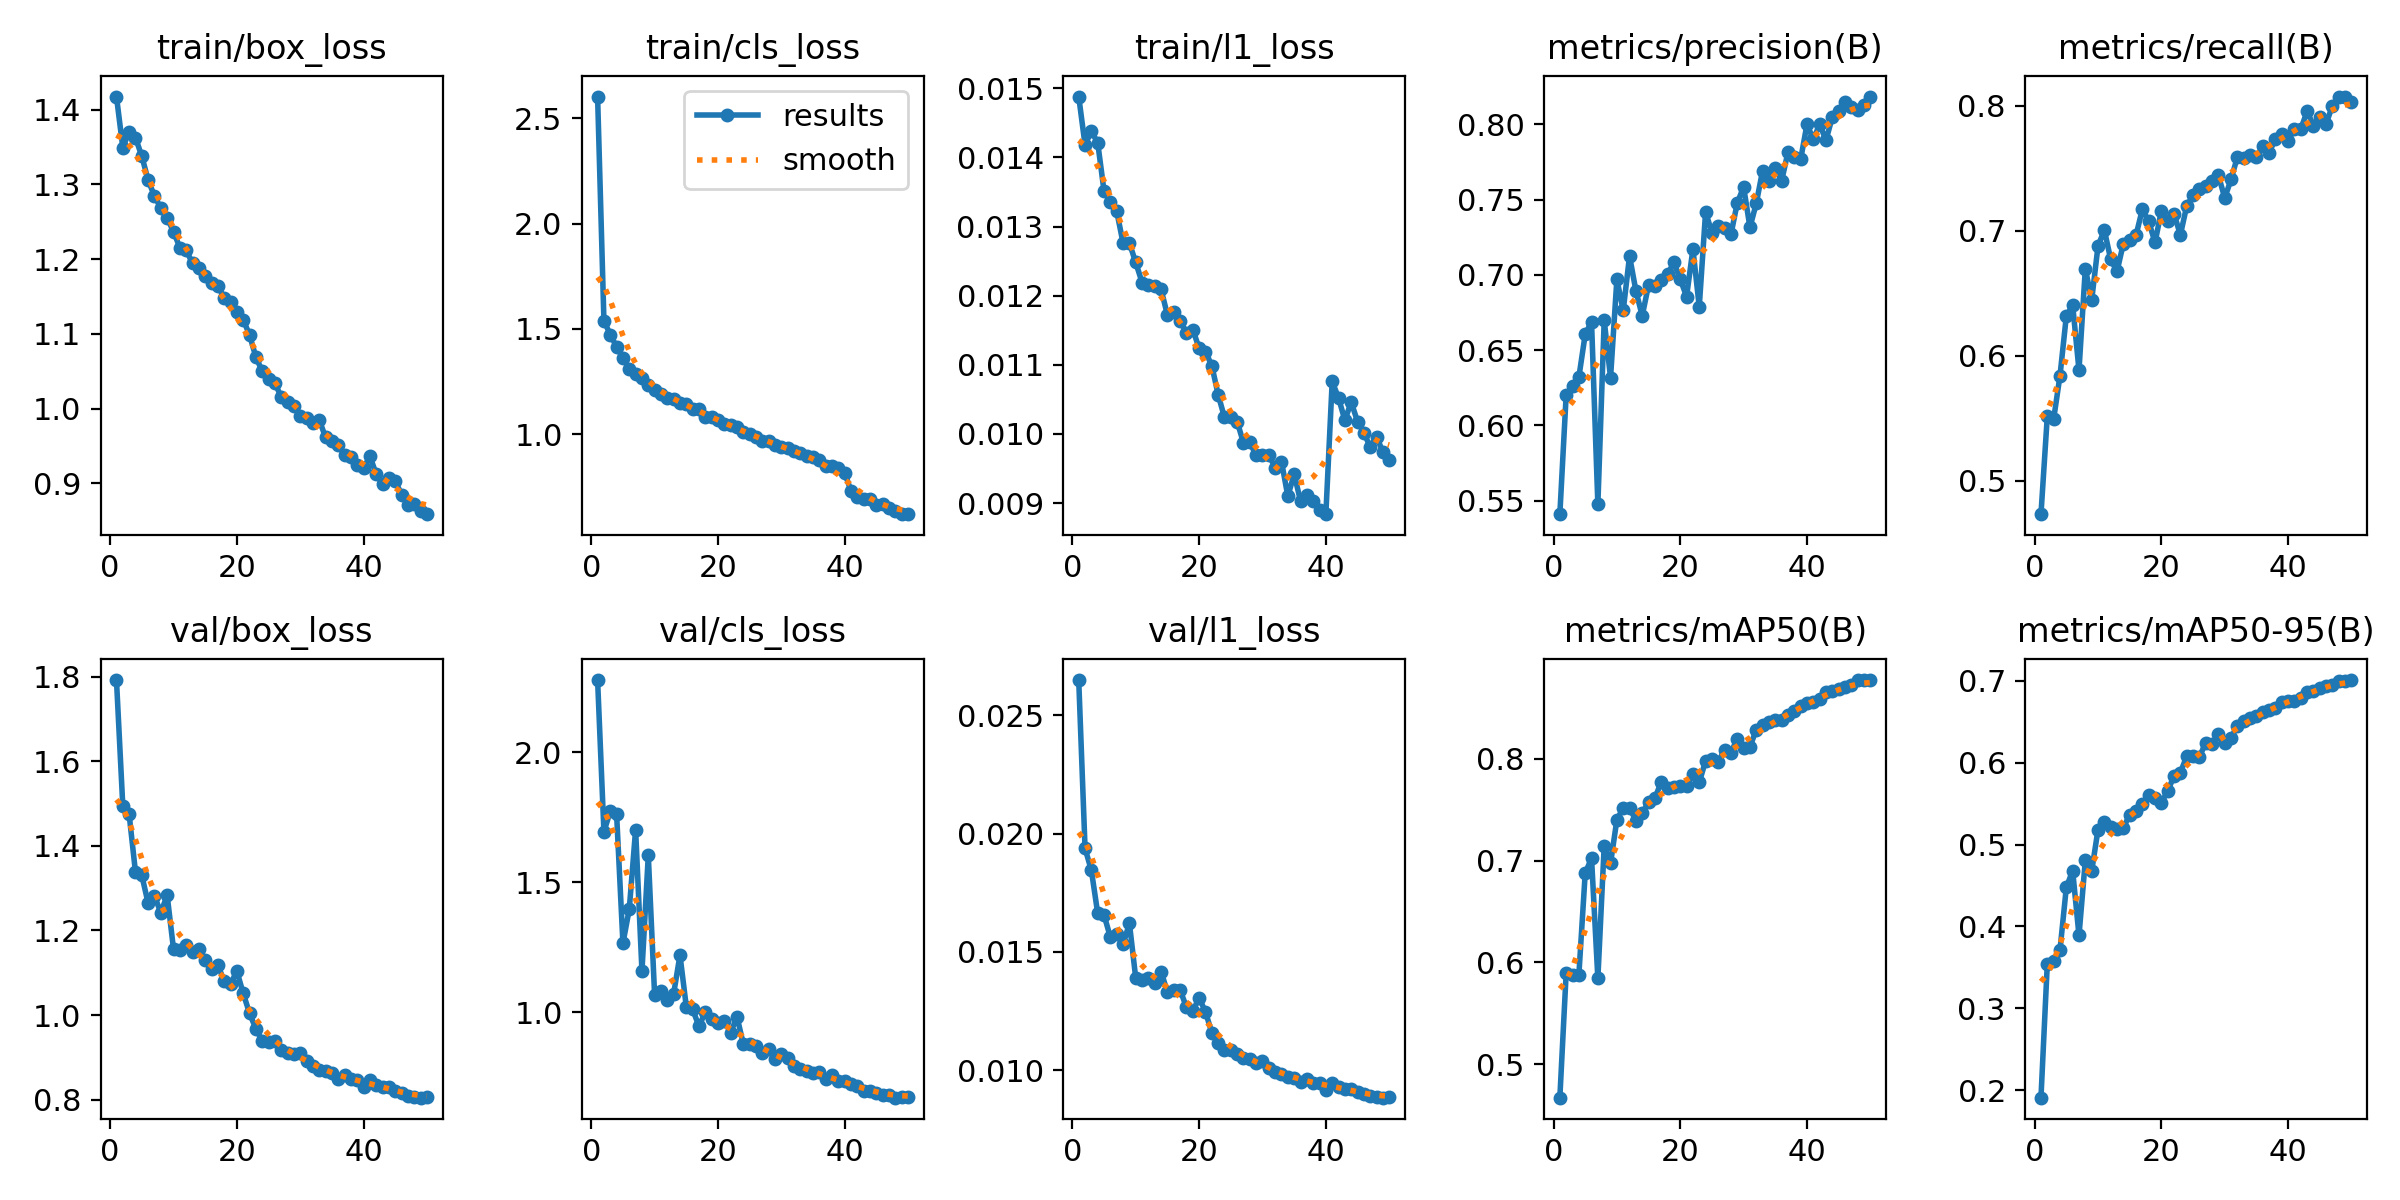

YOLO26s - confusion_matrix.png


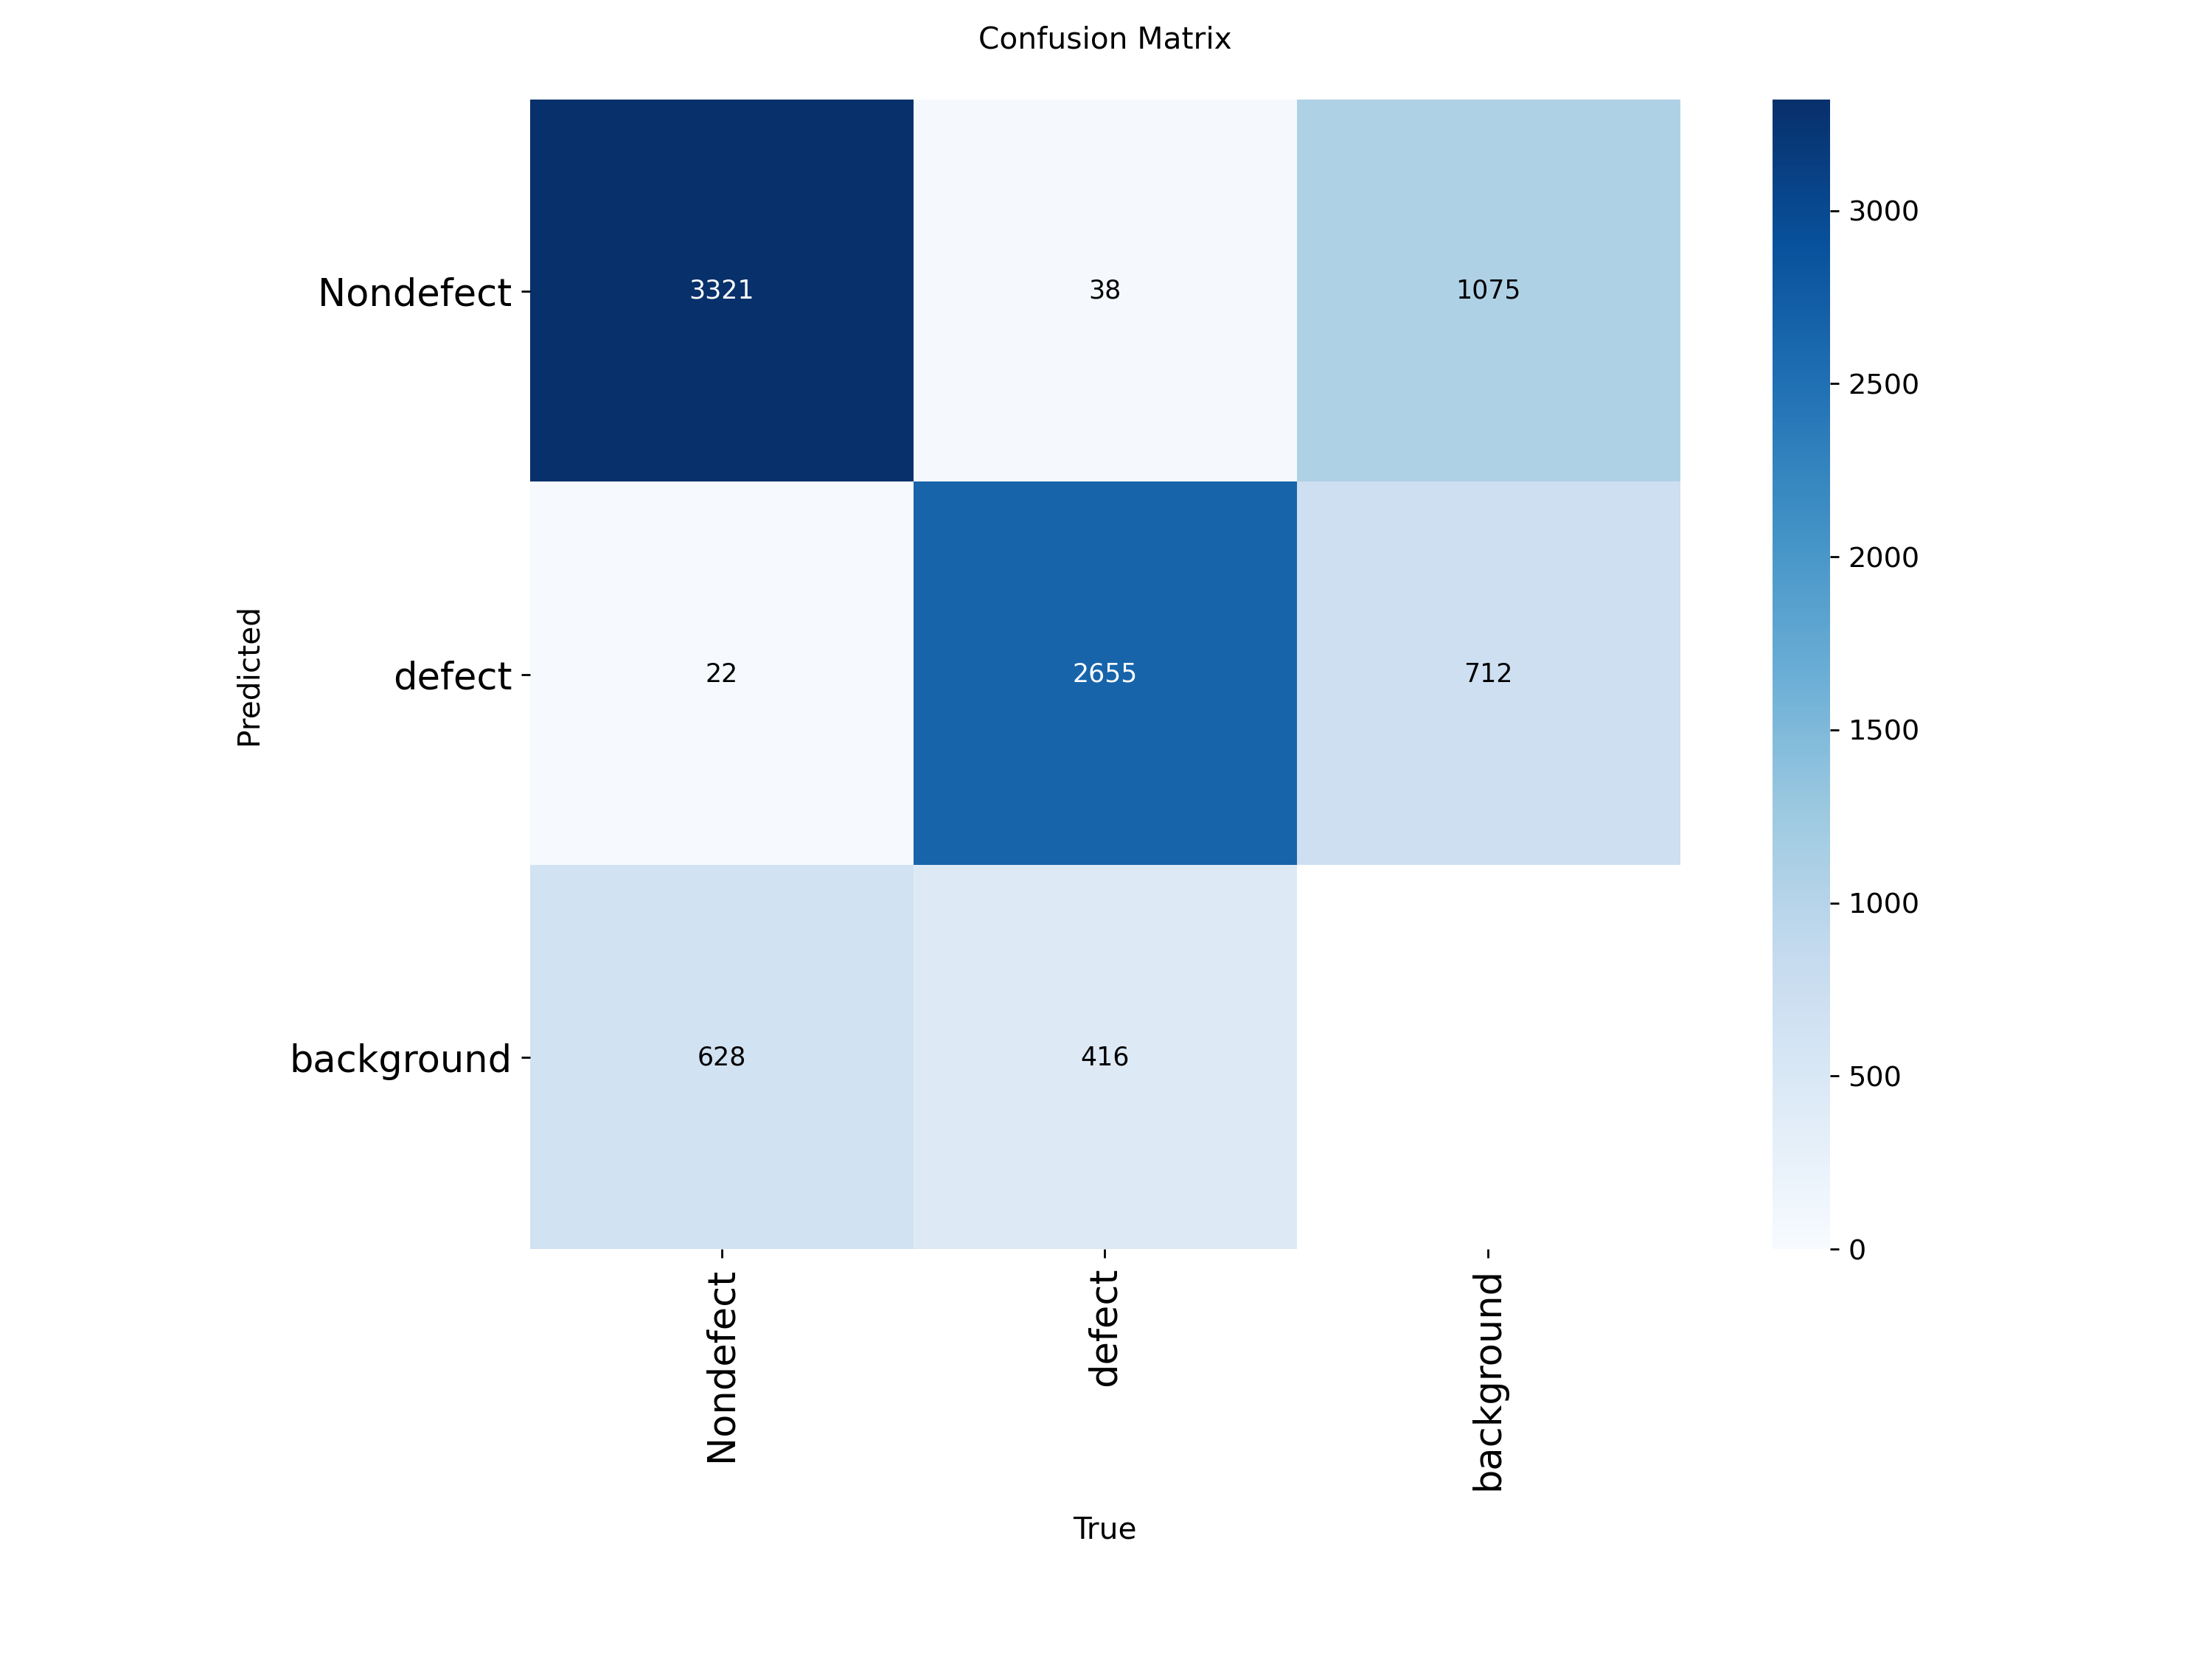

YOLO26s - val_batch0_pred.jpg


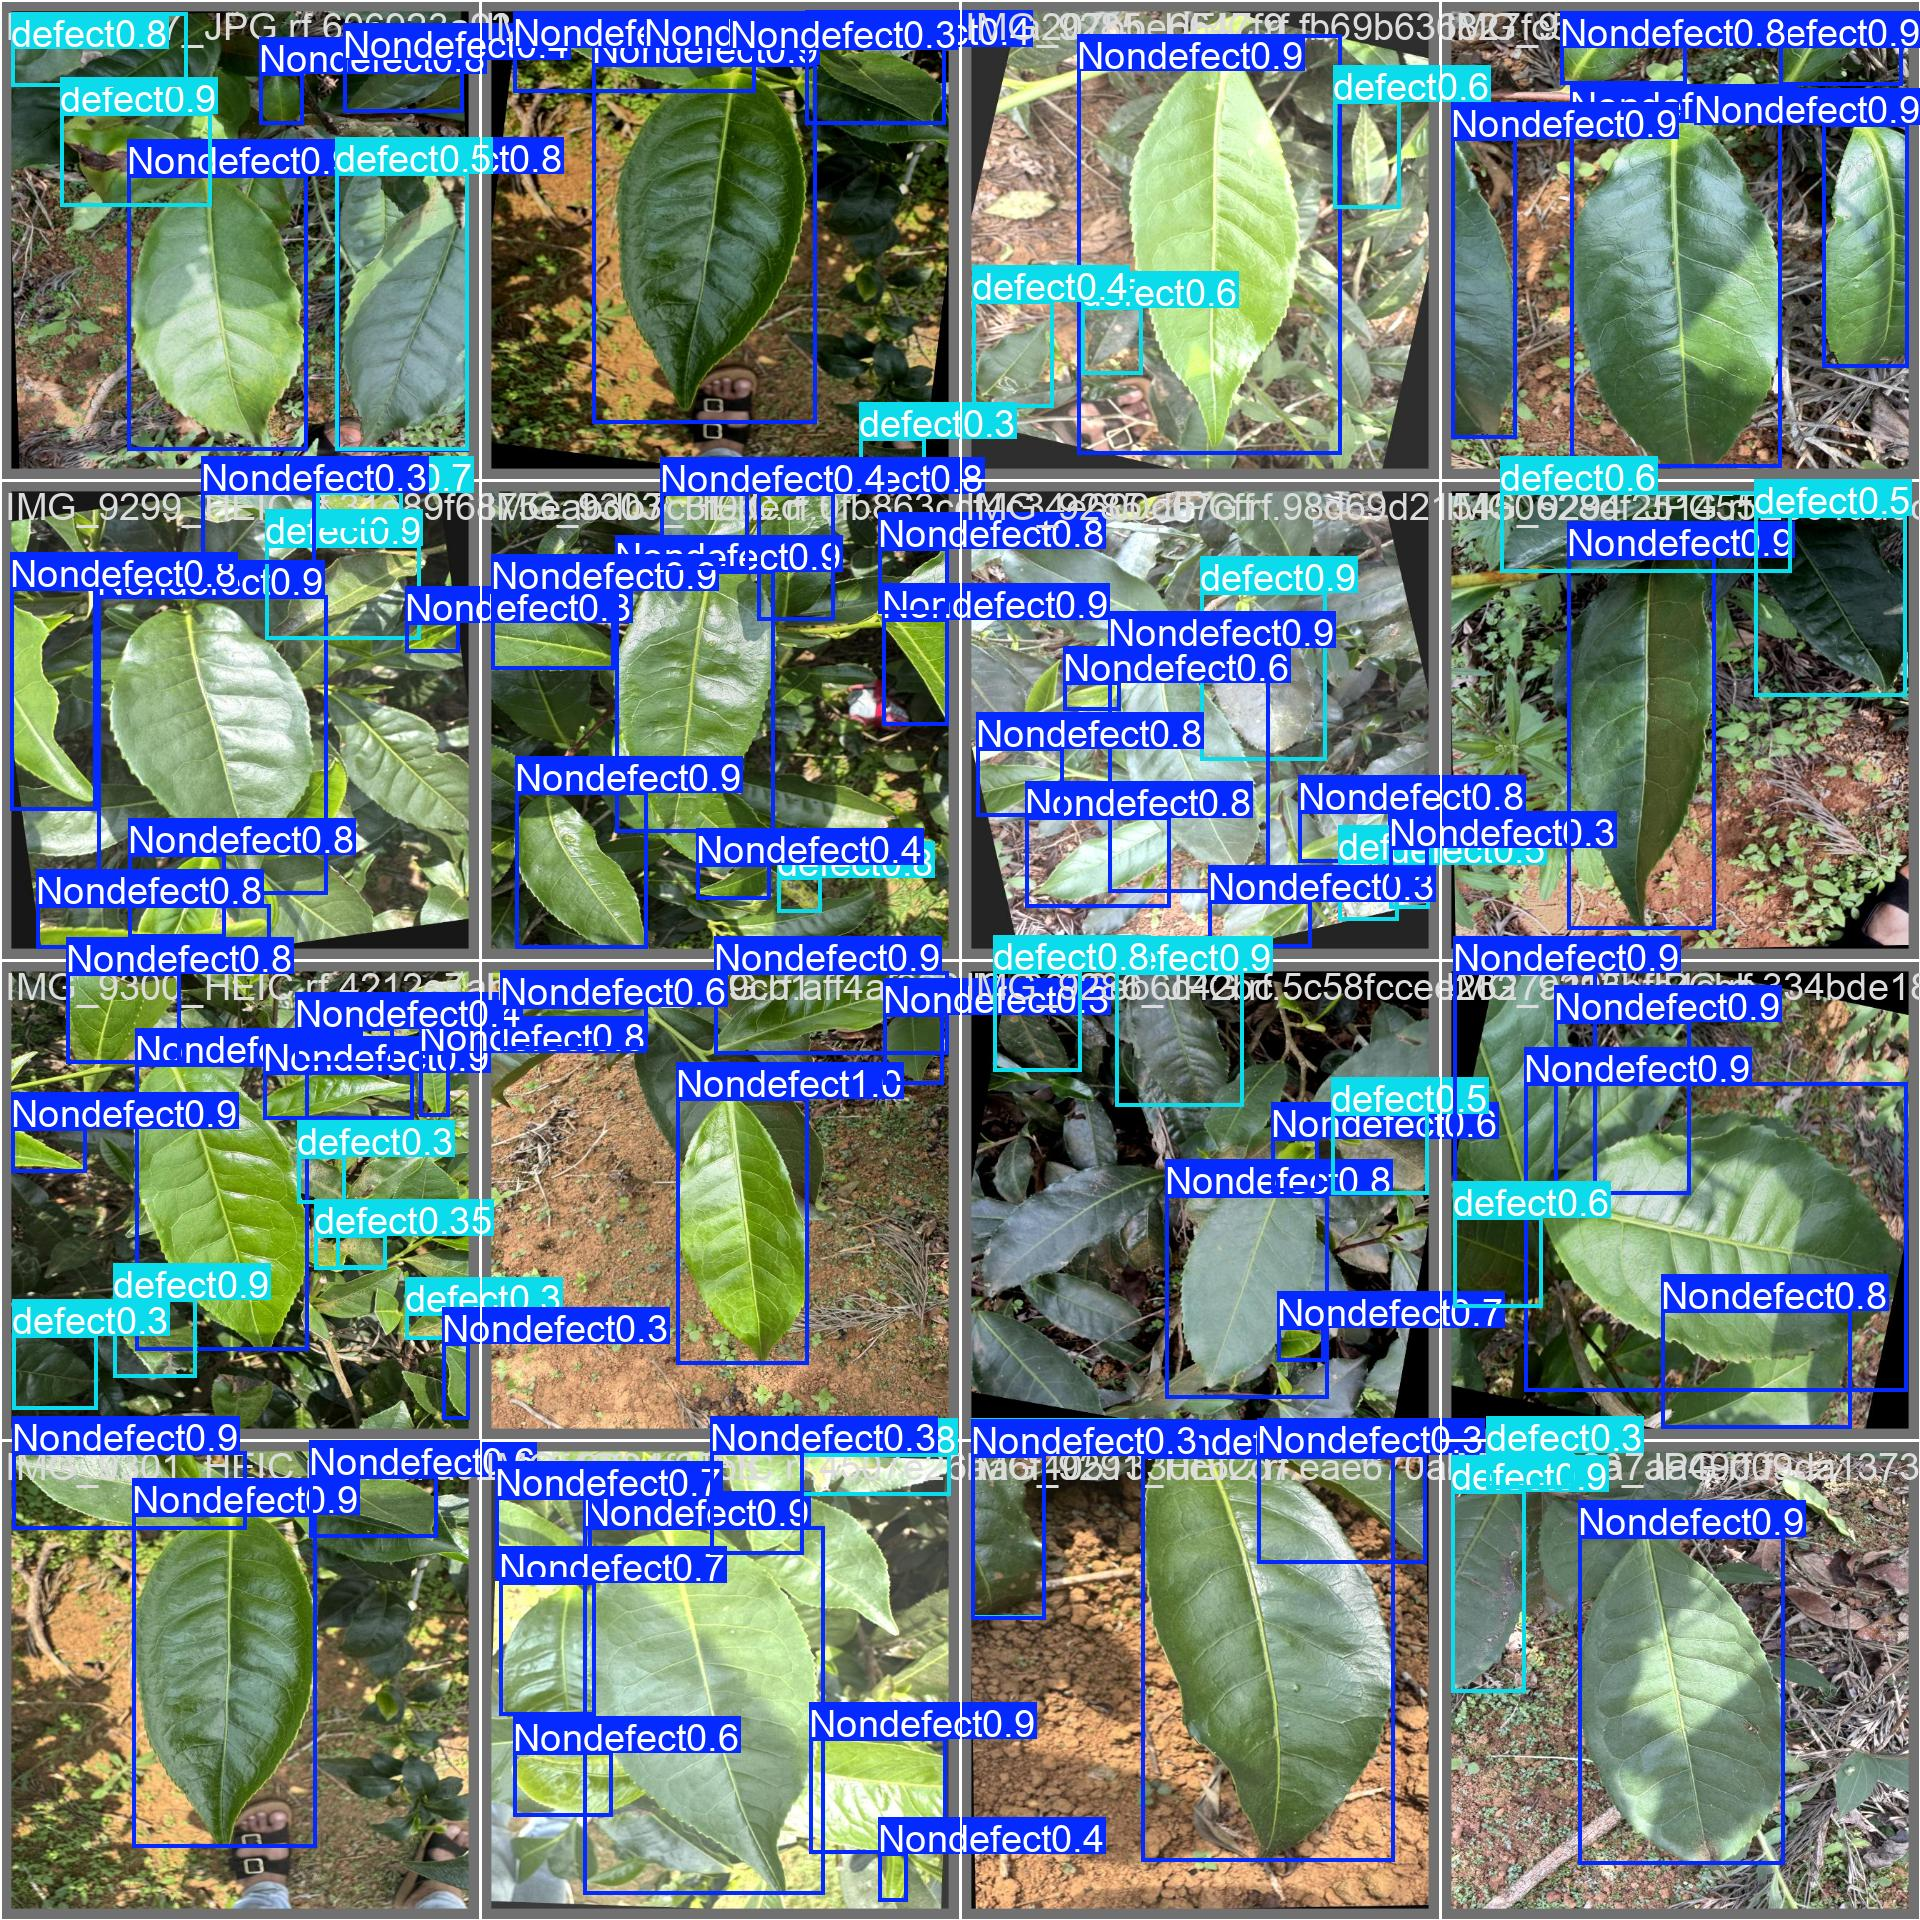

In [32]:
from IPython.display import Image, display
import os

# plots produced by Ultralytics for the winning run
for img in ["results.png", "confusion_matrix.png", "val_batch0_pred.jpg"]:
    p = os.path.join(BEST_RUN_DIR, img)
    if os.path.exists(p):
        print(BEST_NAME, "-", img)
        display(Image(filename=p, width=700))


## 8. Quick sanity-check prediction
Run the model on a few validation images to see the boxes.


0: 640x640 11 Nondefects, 12.8ms
1: 640x640 4 Nondefects, 1 defect, 12.8ms
2: 640x640 12 Nondefects, 1 defect, 12.8ms
Speed: 2.1ms preprocess, 12.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/predict


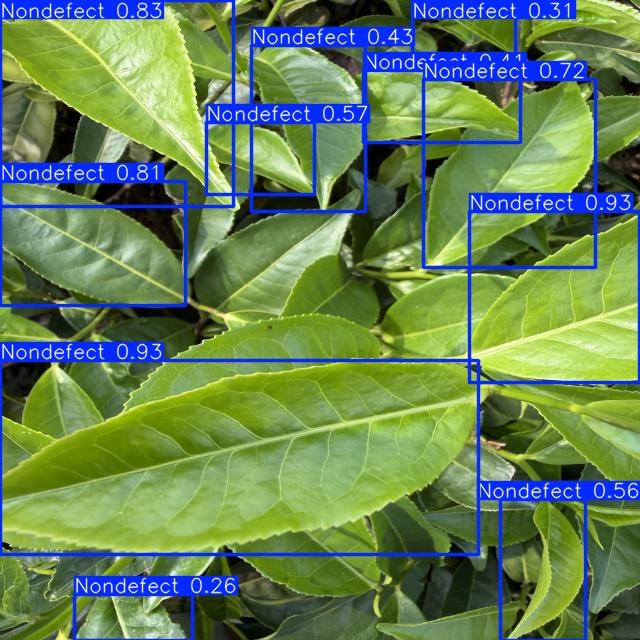

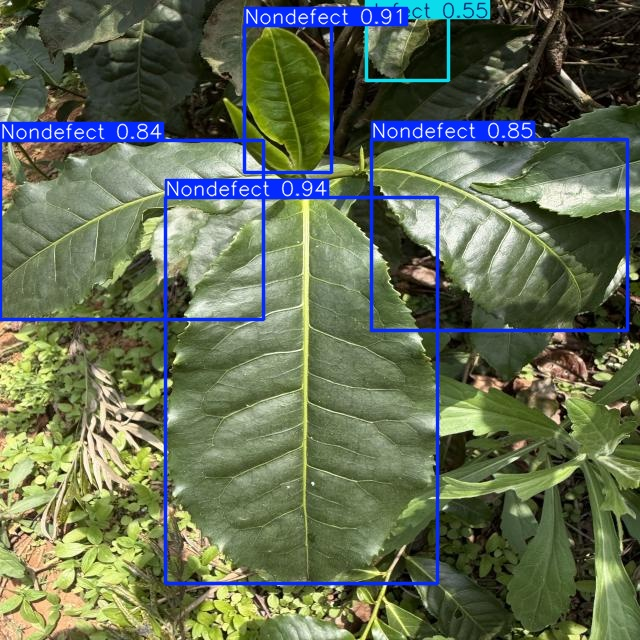

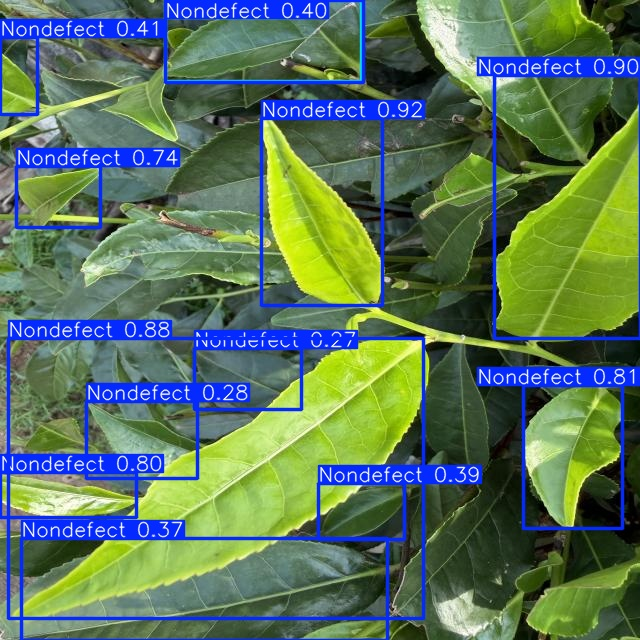

In [33]:
import glob, os
from IPython.display import Image, display

val_images = glob.glob(os.path.join(dataset.location, "valid", "images", "*"))[:3]
if not val_images:
    val_images = glob.glob(os.path.join(dataset.location, "test", "images", "*"))[:3]

pred = best.predict(val_images, conf=0.25, save=True)
for r in pred:
    display(Image(filename=r.save_dir + "/" + os.path.basename(r.path), width=500))

## 9. Export to ONNX (for the browser)
`opset=12` keeps it compatible with **onnxruntime-web**. `simplify=True` shrinks the graph.

The exported file lives next to `best.pt` as `best.onnx`.

In [34]:
# ===== Prepare the winning model for the Raspberry Pi 5 (ARM64 CPU, 640) =====
import os, json, glob, shutil, time
import numpy as np, cv2
from pathlib import Path

PI_DIR   = Path("/kaggle/working/pi5_export")
PI_DIR.mkdir(parents=True, exist_ok=True)
PI_IMGSZ = 640            # keep 640; the Pi's limit is CPU, not its 16 GB RAM
OPSET    = 13             # onnxruntime on ARM64 is happiest at 13+
MAKE_INT8 = True
N_CALIB   = 200

REUSE = False   # True = reuse the comparison export; False = clean re-export

# ---- FP32 ONNX ---------------------------------------------------------------
fp32 = PI_DIR / ("%s_%d_fp32.onnx" % (BEST_NAME, PI_IMGSZ))

if REUSE and BEST_ONNX and os.path.exists(BEST_ONNX):
    shutil.copy2(BEST_ONNX, fp32)
    print("reused the ONNX file from the comparison ->", fp32.name)
else:
    # half=False on purpose: ARM CPU gains nothing from FP16 in ORT and some
    # kernels fall back to slower paths. dynamic=False + batch=1 lets ORT
    # pre-plan memory, which is a real speedup on the Pi.
    src = str(BEST_MODEL.export(format="onnx", opset=OPSET, imgsz=PI_IMGSZ,
                                simplify=True, dynamic=False, batch=1, half=False))
    shutil.move(src, fp32)
    print("exported ->", fp32.name)

print("size: %.1f MB" % (fp32.stat().st_size / 1e6))

# ---- inspect the head instead of guessing from the name ----------------------
import onnxruntime as ort

so = ort.SessionOptions()
so.intra_op_num_threads = 4                      # Pi 5 has 4 Cortex-A76 cores
so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
sess = ort.InferenceSession(str(fp32), so, providers=["CPUExecutionProvider"])
INPUT_NAME = sess.get_inputs()[0].name
out_shapes = [o.shape for o in sess.get_outputs()]
print("input :", INPUT_NAME, sess.get_inputs()[0].shape)
print("output:", out_shapes)

s0 = out_shapes[0]
# (1, N, 6) = x1,y1,x2,y2,conf,cls already decoded -> no NMS needed
# (1, 4+nc, N) = raw head -> the Pi script must run NMS
END_TO_END = len(s0) == 3 and s0[2] == 6
print("NMS-free (end-to-end) output:", END_TO_END,
      "| BEST_NAME says:", BEST_NAME.startswith("YOLO26"))
if END_TO_END != BEST_NAME.startswith("YOLO26"):
    print("  -> name and actual output disagree; trust the output shape.")

# ---- calibration images from the held-out split ------------------------------
DATA_ROOT = os.path.dirname(DATA)
cal_dir = os.path.join(DATA_ROOT, "test", "images")
if not os.path.isdir(cal_dir):
    cal_dir = os.path.join(DATA_ROOT, "valid", "images")
calib_imgs = sorted(glob.glob(os.path.join(cal_dir, "*")))
print("calibration pool:", len(calib_imgs), "from", cal_dir)


def letterbox(im, new=640, color=(114, 114, 114)):
    h, w = im.shape[:2]
    r = min(new / h, new / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    out = np.full((new, new, 3), color, np.uint8)
    top, left = (new - nh) // 2, (new - nw) // 2
    out[top:top + nh, left:left + nw] = cv2.resize(im, (nw, nh))
    return out


def preprocess(path, size=PI_IMGSZ):
    im = cv2.imread(path)
    if im is None:
        return None
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    blob = letterbox(im, size).astype(np.float32) / 255.0
    return np.ascontiguousarray(blob.transpose(2, 0, 1)[None])


def bench(path, blob, n=20, warm=5):
    s = ort.InferenceSession(path, so, providers=["CPUExecutionProvider"])
    nm = s.get_inputs()[0].name
    for _ in range(warm):
        s.run(None, {nm: blob})
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        s.run(None, {nm: blob})
        ts.append((time.perf_counter() - t0) * 1000)
    return float(np.median(ts))


sample = preprocess(calib_imgs[0])
fp32_ms = bench(str(fp32), sample)
print("\nfp32 on this x86 CPU: %.1f ms  (the Pi will be ~4-8x slower)" % fp32_ms)

# ---- INT8 static quantization ------------------------------------------------
int8 = None
if MAKE_INT8:
    from onnxruntime.quantization import (quantize_static, CalibrationDataReader,
                                          QuantFormat, QuantType)

    class Reader(CalibrationDataReader):
        def __init__(self, paths):
            self.paths, self.i = paths, 0
        def get_next(self):
            while self.i < len(self.paths):
                b = preprocess(self.paths[self.i]); self.i += 1
                if b is not None:
                    return {INPUT_NAME: b}
            return None
        def rewind(self):
            self.i = 0

    int8 = PI_DIR / ("%s_%d_int8.onnx" % (BEST_NAME, PI_IMGSZ))
    try:
        # shape inference first; quantization fails on some graphs without it
        prep = PI_DIR / "_prep.onnx"
        try:
            from onnxruntime.quantization.shape_inference import quant_pre_process
            quant_pre_process(str(fp32), str(prep), skip_symbolic_shape=False)
        except Exception:
            shutil.copy2(fp32, prep)

        quantize_static(
            model_input=str(prep), model_output=str(int8),
            calibration_data_reader=Reader(calib_imgs[:N_CALIB]),
            quant_format=QuantFormat.QDQ,        # best supported on ARM64
            activation_type=QuantType.QUInt8,
            weight_type=QuantType.QInt8,
            per_channel=True,                    # keeps conv accuracy up
        )
        prep.unlink(missing_ok=True)
        int8_ms = bench(str(int8), sample)
        print("int8 -> %s (%.1f MB) | x86 %.1f ms (%.2fx faster)"
              % (int8.name, int8.stat().st_size / 1e6, int8_ms, fp32_ms / int8_ms))
    except Exception as e:
        print("INT8 quantization failed: %s" % e)
        int8 = None

# ---- sanity check: do fp32 and int8 agree on real images? --------------------
if int8 and int8.exists():
    s32 = ort.InferenceSession(str(fp32), so, providers=["CPUExecutionProvider"])
    s8  = ort.InferenceSession(str(int8),  so, providers=["CPUExecutionProvider"])
    n_ok = 0
    for p in calib_imgs[:20]:
        b = preprocess(p)
        if b is None:
            continue
        a = s32.run(None, {INPUT_NAME: b})[0]
        c = s8.run(None, {s8.get_inputs()[0].name: b})[0]
        if END_TO_END:
            d32 = int((a[0][:, 4] >= 0.25).sum()); d8 = int((c[0][:, 4] >= 0.25).sum())
        else:
            f = lambda x: x[0].T if x[0].shape[0] < x[0].shape[1] else x[0]
            d32 = int((f(a)[:, 4:].max(1) >= 0.25).sum())
            d8  = int((f(c)[:, 4:].max(1) >= 0.25).sum())
        n_ok += abs(d32 - d8) <= max(1, 0.25 * max(d32, 1))
    print("\nint8 matched fp32 detection counts on %d/20 images" % n_ok)
    if n_ok < 15:
        print("  -> large drift. Validate INT8 mAP before trusting it on the Pi.")

# ---- metadata the Pi script reads -------------------------------------------
meta = {
    "model": BEST_NAME,
    "imgsz": PI_IMGSZ,
    "class_names": CLASS_NAMES,
    "nc": len(CLASS_NAMES),
    "end_to_end": bool(END_TO_END),
    "input_name": INPUT_NAME,
    "output_shapes": [list(s) for s in out_shapes],
    "preprocess": "RGB, letterbox 114, /255, NCHW float32",
    "fp32": fp32.name,
    "int8": int8.name if int8 and int8.exists() else None,
}
(PI_DIR / "metadata.json").write_text(json.dumps(meta, indent=2))

onnx_path = str(int8) if (int8 and int8.exists()) else str(fp32)
PI_MODEL  = onnx_path
print("\nPi deployment file:", PI_MODEL)
for f in sorted(PI_DIR.iterdir()):
    print("  %-36s %6.1f MB" % (f.name, f.stat().st_size / 1e6))


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs

PyTorch: starting from '/kaggle/working/runs/YOLO26s/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (19.4 MB)

ONNX: starting export with onnx 1.22.0 opset 13...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.6s, saved as '/kaggle/working/runs/YOLO26s/weights/best.onnx' (36.4 MB)

Export complete (3.5s)
Results saved to /kaggle/working/runs/YOLO26s/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/YOLO26s/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/YOLO26s/weights/best.onnx imgsz=640 data=/kaggle/working/dataset_split/data.yaml  
Visualize:       https://netron.app
exported -> YOLO26s

## 10. Download the trained model
Downloads `best.onnx` (for the website) and `best.pt` (backup).

➡️ Put **`best.onnx`** into the website's `model/` folder and rename it if needed (the website expects `model/best.onnx`).

In [35]:
# ===== Collect the results into /kaggle/working =====
# Kaggle has no browser download during a session. Press "Save Version" when the
# run finishes: everything under /kaggle/working is kept as that version's
# output, downloadable from the Output tab and attachable to a later session.
import shutil, os, json
from pathlib import Path

WORK    = Path(globals().get("WORK", "/kaggle/working"))
PERSIST = Path(globals().get("PERSIST", WORK / "tea_thesis"))
PERSIST.mkdir(parents=True, exist_ok=True)

def grab(src, dst_name):
    """Copy one file into PERSIST, reporting instead of raising if absent."""
    if not src:
        print("  skip %s (not defined)" % dst_name); return False
    src = Path(str(src))
    if not src.exists():
        print("  skip %s (missing: %s)" % (dst_name, src)); return False
    shutil.copy2(src, PERSIST / dst_name)
    print("  %-34s %6.1f MB" % (dst_name, src.stat().st_size / 1e6))
    return True

print("collecting into", PERSIST)

# ---- PyTorch weights ---------------------------------------------------------
grab(BEST_PT, "%s_best.pt" % BEST_NAME)

# ---- ONNX: keep BOTH variants, named so you can tell them apart --------------
# onnx_path points at whichever variant is preferred for the Pi (int8 if it
# quantized cleanly). Ship fp32 too: it is the fallback if int8 accuracy drifts.
pi_files = []
if "PI_DIR" in globals():
    for f in sorted(Path(PI_DIR).iterdir()):
        if f.is_file():
            shutil.copy2(f, PERSIST / f.name)
            pi_files.append(f.name)
            print("  %-34s %6.1f MB" % (f.name, f.stat().st_size / 1e6))
else:
    grab(onnx_path, "%s_640.onnx" % BEST_NAME)

# ---- comparison artefacts ----------------------------------------------------
for fn in ("model_comparison.csv", "table_model_comparison.tex", "comparison.json"):
    src = Path(FIG_DIR) / fn
    if src.exists():
        grab(src, fn)

grab(STATE, "train_state.json")

# ---- a compact summary so the numbers travel with the weights ----------------
summary = {
    "winner": BEST_NAME,
    "imgsz": globals().get("PI_IMGSZ", IMGSZ),
    "classes": CLASS_NAMES,
    "eval_split": globals().get("EVAL_SPLIT"),
    "dataset": os.path.dirname(DATA),
    "pi_deploy_file": os.path.basename(str(onnx_path)),
    "runs": {n: {k: v for k, v in r.items() if k != "per_class"}
             for n, r in RUNS.items()},
}
try:
    summary["comparison"] = json.loads(
        cmp_df.drop(columns=["per_class"], errors="ignore").to_json(orient="index"))
except Exception:
    pass
(PERSIST / "summary.json").write_text(json.dumps(summary, indent=2))
print("  summary.json")

# ---- figures + one zip of the whole Pi bundle --------------------------------
if "FIG_DIR" in globals() and Path(FIG_DIR).is_dir():
    shutil.make_archive(str(WORK / "thesis_figures"), "zip", str(FIG_DIR))
    print("\nzipped figures -> %s" % (WORK / "thesis_figures.zip"))

if "PI_DIR" in globals() and Path(PI_DIR).is_dir():
    shutil.make_archive(str(WORK / "pi5_export"), "zip", str(PI_DIR))
    print("zipped Pi bundle -> %s (%s)"
          % (WORK / "pi5_export.zip", ", ".join(pi_files)))

# ---- final listing -----------------------------------------------------------
print("\ncontents of", PERSIST)
total = 0
for f in sorted(PERSIST.iterdir()):
    mb = f.stat().st_size / 1e6
    total += mb
    print("   %-36s %7.1f MB" % (f.name, mb))
print("   %-36s %7.1f MB" % ("TOTAL", total))

print("\nNow press Save Version to keep these files.")
print("On the Pi:  unzip pi5_export.zip && python pi_infer.py "
      "--model %s --source test.jpg" % os.path.basename(str(onnx_path)))

# push_to_drive()   # uncomment if the optional rclone step was configured

collecting into /kaggle/working/tea_thesis
  YOLO26s_best.pt                      20.3 MB
  YOLO11s_640_fp32.onnx                37.9 MB
  YOLO11s_640_int8.onnx                10.1 MB
  YOLO12s_640_fp32.onnx                37.3 MB
  YOLO12s_640_int8.onnx                10.3 MB
  YOLO26s_640_fp32.onnx                38.2 MB
  YOLO26s_640_int8.onnx                10.3 MB
  metadata.json                         0.0 MB
  model_comparison.csv                  0.0 MB
  table_model_comparison.tex            0.0 MB
  comparison.json                       0.0 MB
  train_state.json                      0.0 MB
  summary.json

zipped figures -> /kaggle/working/thesis_figures.zip
zipped Pi bundle -> /kaggle/working/pi5_export.zip (YOLO11s_640_fp32.onnx, YOLO11s_640_int8.onnx, YOLO12s_640_fp32.onnx, YOLO12s_640_int8.onnx, YOLO26s_640_fp32.onnx, YOLO26s_640_int8.onnx, metadata.json)

contents of /kaggle/working/tea_thesis
   YOLO11s_640_fp32.onnx                   37.9 MB
   YOLO11s_640_int8.onnx    

## 11. Generate the figures for the thesis

Everything below writes **publication-quality PNGs at 300 dpi** into `thesis_figures/`,
plus a ready-to-paste LaTeX results table, then zips and downloads them.

Run these cells **after** training (Step 5) and export (Step 9). Each cell stands alone,
so if one fails the others still work. `INDEX.md` in the zip maps every figure to the
thesis section it belongs in.


### 11.1 Setup and path discovery

In [36]:
# ===== Thesis figures: setup =====
import os, glob, shutil, random, time
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import cv2, yaml

FIG_DIR = Path(globals().get("FIG_DIR", "/kaggle/working/tea_thesis/thesis_figures"))
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})

def save(fig, name):
    p = FIG_DIR / name
    fig.savefig(p); plt.close(fig); print("saved", p)
    return p

def _find_run_dir():
    c = [d for d in glob.glob("/kaggle/working/runs/*") + glob.glob("runs/detect/*")
         if os.path.isdir(os.path.join(d, "weights"))]
    return max(c, key=os.path.getmtime) if c else None

# ---- dataset: the 80/15/5 RE-SPLIT, never the original Roboflow download -----
# dataset.location points at /kaggle/working/dataset, which has no test folder
# and whose 44 valid images were pooled into training when the split was built.
DATA_YAML = globals().get("DATA") or globals().get("new_yaml_path")
if not DATA_YAML or not os.path.exists(DATA_YAML):
    raise RuntimeError("DATA (re-split data.yaml) not found. Run the split cell first.")
DATA_DIR = os.path.dirname(DATA_YAML)

RUN_DIR   = globals().get("BEST_RUN_DIR") or globals().get("run_dir") or _find_run_dir()
BEST_PT   = globals().get("BEST_PT") or (
    os.path.join(RUN_DIR, "weights", "best.pt") if RUN_DIR else "best.pt")
BEST_ONNX = globals().get("PI_MODEL") or globals().get("onnx_path") or (
    os.path.join(RUN_DIR, "weights", "best.onnx") if RUN_DIR else "best.onnx")

_cfg   = yaml.safe_load(open(DATA_YAML))
_names = _cfg["names"]
CLASS_NAMES = [_names[k] for k in sorted(_names)] if isinstance(_names, dict) else list(_names)
NC = len(CLASS_NAMES)

def class_color(i):
    n = CLASS_NAMES[i].lower()
    if any(k in n for k in ["nondefect", "good", "healthy"]): return "#2a9d5c"
    if any(k in n for k in ["defect", "bad", "disease"]):     return "#d1495b"
    return ["#3d6fb4", "#e0a458", "#8e6bbf", "#4bb3b3"][i % 4]
COLORS = [class_color(i) for i in range(NC)]

def hex2rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

from ultralytics import YOLO
MODEL = globals().get("BEST_MODEL") or globals().get("best") or YOLO(BEST_PT)
MODEL_NAME = globals().get("BEST_NAME", os.path.basename(str(RUN_DIR or "model")))

def split_dir(s):
    p = os.path.join(DATA_DIR, s)
    return p if os.path.isdir(os.path.join(p, "images")) else None

VAL_DIRNAME = "valid" if split_dir("valid") else "val"
TEST_SPLIT  = "test" if split_dir("test") else VAL_DIRNAME
IMGSZ       = globals().get("IMGSZ", 640)
SEED        = globals().get("SEED", 0)
random.seed(SEED); np.random.seed(SEED)     # reproducible sample-image figures

print("DATA_YAML :", DATA_YAML)
print("DATA_DIR  :", DATA_DIR)
print("RUN_DIR   :", RUN_DIR)
print("MODEL     :", MODEL_NAME)
print("BEST_PT   :", BEST_PT, os.path.exists(BEST_PT))
print("BEST_ONNX :", BEST_ONNX, os.path.exists(BEST_ONNX))
print("CLASSES   :", CLASS_NAMES)
print("FIG_DIR   :", FIG_DIR)
print("\nsplit sizes:")
for s in ("train", VAL_DIRNAME, "test"):
    d = split_dir(s)
    n = len(glob.glob(os.path.join(d, "images", "*"))) if d else 0
    mark = "  <- figures use this" if s == TEST_SPLIT else ""
    print("  %-6s %5d images%s" % (s, n, mark))
if TEST_SPLIT != "test":
    print("\nWARNING: no test folder found; figures will use the valid split, "
          "which best.pt was selected against. Numbers will be optimistic.")

DATA_YAML : /kaggle/working/dataset_split/data.yaml
DATA_DIR  : /kaggle/working/dataset_split
RUN_DIR   : /kaggle/working/runs/YOLO26s
MODEL     : YOLO26s
BEST_PT   : /kaggle/working/runs/YOLO26s/weights/best.pt True
BEST_ONNX : /kaggle/working/pi5_export/YOLO26s_640_int8.onnx True
CLASSES   : ['Nondefect', 'defect']
FIG_DIR   : /kaggle/working/tea_thesis/thesis_figures

split sizes:
  train  10504 images
  valid   1968 images
  test     330 images  <- figures use this


### 11.2 Dataset composition and class balance
*Thesis: Chapter 3 (Dataset and class taxonomy), Chapter 4 (Dataset).*

In [37]:
# ===== Dataset statistics =====
stats, all_boxes = {}, []
SPLITS = ["train", VAL_DIRNAME, "test"]

for s in SPLITS:
    d = split_dir(s)
    if not d:
        continue
    imgs = sorted(glob.glob(os.path.join(d, "images", "*")))
    counts, per_img = np.zeros(NC, int), []
    lbls = sorted(glob.glob(os.path.join(d, "labels", "*.txt")))
    for lf in lbls:
        n = 0
        for line in open(lf):
            p = line.split()
            if len(p) < 5:
                continue
            c = int(float(p[0])); cx, cy, bw, bh = map(float, p[1:5])
            if 0 <= c < NC:
                counts[c] += 1; n += 1
                all_boxes.append((c, bw, bh, cx, cy, SPLITS.index(s)))
        per_img.append(n)
    # images with no label file at all are background images, still counted
    per_img += [0] * max(0, len(imgs) - len(lbls))
    stats[s] = {"images": len(imgs), "labels": len(lbls),
                "counts": counts, "per_img": per_img}
    print("%-6s images=%-5d labels=%-5d instances=%-6d %s"
          % (s, len(imgs), len(lbls), counts.sum(),
             dict(zip(CLASS_NAMES, counts))))

# ---- class balance ratio, the number the thesis needs to state --------------
tot = sum(v["counts"] for v in stats.values())
print("\noverall: %s" % dict(zip(CLASS_NAMES, tot.astype(int))))
if tot.min() > 0:
    print("imbalance ratio (max:min) = %.2f : 1" % (tot.max() / tot.min()))
for s, v in stats.items():
    frac = v["counts"] / max(1, v["counts"].sum())
    print("  %-6s %s" % (s, "  ".join("%s %.1f%%" % (c, f * 100)
                                      for c, f in zip(CLASS_NAMES, frac))))

# ---- figure 1: composition --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(NC); w = 0.8 / max(len(stats), 1)
for i, (s, v) in enumerate(stats.items()):
    b = axes[0].bar(x + i * w - 0.4 + w / 2, v["counts"], w, label=s)
    axes[0].bar_label(b, fmt="%d", fontsize=7, padding=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel("annotated instances")
axes[0].set_title("Class distribution by split")
axes[0].set_yscale("log")          # train dwarfs test at 80/15/5; log keeps both readable
axes[0].legend()

b = axes[1].bar(list(stats), [v["images"] for v in stats.values()], color="#3d6fb4")
axes[1].bar_label(b, fmt="%d")
axes[1].set_ylabel("images"); axes[1].set_title("Images per split")
save(fig, "fig_dataset_composition.png")

# ---- figure 2: overall balance ----------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
b = ax.bar(CLASS_NAMES, tot, color=COLORS)
ax.bar_label(b, fmt="%d")
ax.set_ylabel("instances")
ax.set_title("Overall class balance (%d instances)" % int(tot.sum()))
ax.set_ylim(0, tot.max() * 1.12)
save(fig, "fig_class_balance.png")

# ---- figure 3: box statistics -----------------------------------------------
if all_boxes:
    arr = np.array(all_boxes)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    pia = [n for v in stats.values() for n in v["per_img"]]
    hi = int(np.percentile(pia, 99)) + 1          # clip the tail so bars stay visible
    axes[0].hist(np.clip(pia, 0, hi), bins=range(0, hi + 2),
                 color="#3d6fb4", edgecolor="white")
    axes[0].set_xlabel("boxes per image (clipped at p99 = %d)" % hi)
    axes[0].set_ylabel("images")
    axes[0].set_title("Objects per image (mean %.1f, max %d)"
                      % (np.mean(pia), max(pia)))

    area = arr[:, 1] * arr[:, 2]
    bins = np.logspace(np.log10(max(area.min(), 1e-6)), np.log10(area.max()), 40)
    for c in range(NC):
        m = arr[:, 0] == c
        if m.any():
            axes[1].hist(area[m], bins=bins, alpha=0.6,
                         label="%s (n=%d)" % (CLASS_NAMES[c], m.sum()), color=COLORS[c])
    axes[1].set_xscale("log")
    axes[1].axvline(32 * 32 / (IMGSZ ** 2), ls="--", c="gray", lw=1)
    axes[1].text(32 * 32 / (IMGSZ ** 2), axes[1].get_ylim()[1] * 0.9,
                 " COCO 'small'", fontsize=8, color="gray")
    axes[1].set_xlabel("box area (fraction of image)")
    axes[1].set_ylabel("count")
    axes[1].set_title("Object size distribution")
    axes[1].legend(fontsize=8)

    axes[2].scatter(arr[:, 3], arr[:, 4], s=3, alpha=0.15,
                    c=[COLORS[int(c)] for c in arr[:, 0]])
    axes[2].set_xlim(0, 1); axes[2].set_ylim(1, 0); axes[2].set_aspect("equal")
    axes[2].set_xlabel("x centre"); axes[2].set_ylabel("y centre")
    axes[2].set_title("Object centre positions")
    axes[2].grid(alpha=0.2)
    save(fig, "fig_bbox_statistics.png")

    # ---- small-object share, relevant to the 640 vs Pi trade-off ------------
    small = (area < 32 * 32 / (IMGSZ ** 2)).mean()
    print("\nboxes smaller than COCO-'small' at %d px: %.1f%%" % (IMGSZ, small * 100))
    print("median box area: %.5f of image (%.0f px at %d)"
          % (np.median(area), np.median(area) * IMGSZ ** 2, IMGSZ))

# ---- CSV for the thesis appendix --------------------------------------------
import pandas as pd
rows = []
for s, v in stats.items():
    r = {"split": s, "images": v["images"], "instances": int(v["counts"].sum()),
         "boxes_per_image": round(float(np.mean(v["per_img"])), 2)}
    r.update({c: int(n) for c, n in zip(CLASS_NAMES, v["counts"])})
    rows.append(r)
ds_df = pd.DataFrame(rows).set_index("split")
ds_df.to_csv(FIG_DIR / "table_dataset_stats.csv")
print()
print(ds_df.to_string())

train  images=10504 labels=5252  instances=36527  {'Nondefect': np.int64(20584), 'defect': np.int64(15943)}
valid  images=1968  labels=984   instances=7080   {'Nondefect': np.int64(3971), 'defect': np.int64(3109)}
test   images=330   labels=330   instances=2314   {'Nondefect': np.int64(1326), 'defect': np.int64(988)}

overall: {'Nondefect': np.int64(25881), 'defect': np.int64(20040)}
imbalance ratio (max:min) = 1.29 : 1
  train  Nondefect 56.4%  defect 43.6%
  valid  Nondefect 56.1%  defect 43.9%
  test   Nondefect 57.3%  defect 42.7%
saved /kaggle/working/tea_thesis/thesis_figures/fig_dataset_composition.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_class_balance.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_bbox_statistics.png

boxes smaller than COCO-'small' at 640 px: 0.7%
median box area: 0.03971 of image (16264 px at 640)

       images  instances  boxes_per_image  Nondefect  defect
split                                                       
train   10504    

### 11.3 Annotated dataset samples
*Thesis: Chapter 4 (Data annotation and preparation).*

In [38]:
# ===== Ground-truth sample grid =====
from matplotlib.patches import Patch

def draw_gt(img_path, lbl_path):
    im = cv2.imread(img_path)
    if im is None:
        return None, np.zeros(NC, int)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    H, W = im.shape[:2]
    thick = max(2, int(round(min(H, W) / 320)))   # scale with resolution
    counts = np.zeros(NC, int)
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            p = line.split()
            if len(p) < 5:
                continue
            c = int(float(p[0])); cx, cy, bw, bh = map(float, p[1:5])
            if not (0 <= c < NC):
                continue
            x1, y1 = int((cx - bw / 2) * W), int((cy - bh / 2) * H)
            x2, y2 = int((cx + bw / 2) * W), int((cy + bh / 2) * H)
            cv2.rectangle(im, (x1, y1), (x2, y2), hex2rgb(class_color(c)), thick)
            counts[c] += 1
    # colour alone carries the class; a shared legend replaces per-box text,
    # which is unreadable at ~7 boxes per image
    return im, counts


_d = split_dir("train") or split_dir(VAL_DIRNAME)
_imgs = sorted(glob.glob(os.path.join(_d, "images", "*")))

# index images by which classes they contain, so the grid is guaranteed to
# show the rarer class rather than whatever a blind sample happens to pick
by_class = {c: [] for c in range(NC)}
labelled = []
for ip in _imgs:
    lp = os.path.join(_d, "labels", Path(ip).stem + ".txt")
    if not os.path.exists(lp):
        continue
    present = set()
    for line in open(lp):
        p = line.split()
        if len(p) >= 5:
            c = int(float(p[0]))
            if 0 <= c < NC:
                present.add(c)
    if present:
        labelled.append(ip)
        for c in present:
            by_class[c].append(ip)

print("images with labels:", len(labelled))
for c in range(NC):
    print("  %-12s appears in %d images" % (CLASS_NAMES[c], len(by_class[c])))

random.seed(SEED)
PICK, seen = [], set()
for c in range(NC):                       # at least 2 images per class
    for ip in random.sample(by_class[c], min(2, len(by_class[c]))):
        if ip not in seen:
            PICK.append(ip); seen.add(ip)
pool = [i for i in labelled if i not in seen]
PICK += random.sample(pool, min(6 - len(PICK), len(pool)))
PICK = PICK[:6]

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, ip in zip(axes.ravel(), PICK):
    im, counts = draw_gt(ip, os.path.join(_d, "labels", Path(ip).stem + ".txt"))
    if im is None:
        ax.axis("off"); continue
    ax.imshow(im); ax.axis("off")
    ax.set_title(", ".join("%d %s" % (n, c)
                           for c, n in zip(CLASS_NAMES, counts) if n),
                 fontsize=9)
for ax in axes.ravel()[len(PICK):]:
    ax.axis("off")

fig.legend(handles=[Patch(facecolor=COLORS[i], label=CLASS_NAMES[i])
                    for i in range(NC)],
           loc="lower center", ncol=NC, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Annotated samples from the training split (ground truth)")
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
save(fig, "fig_dataset_samples.png")

images with labels: 10504
  Nondefect    appears in 8310 images
  defect       appears in 7688 images
saved /kaggle/working/tea_thesis/thesis_figures/fig_dataset_samples.png


PosixPath('/kaggle/working/tea_thesis/thesis_figures/fig_dataset_samples.png')

### 11.4 Letterbox preprocessing
Shows exactly what `app.js` does to every frame before inference, and why a plain
resize would be wrong. *Thesis: Chapter 3 (Inference pipeline), Chapter 4 (Preprocessing).*

In [41]:
# ===== Letterbox illustration =====
def letterbox(im, new=640, color=(114, 114, 114)):
    h, w = im.shape[:2]
    r = min(new / h, new / w)
    nh, nw = int(round(h * r)), int(round(w * r))
    out = np.full((new, new, 3), color, np.uint8)
    top, left = (new - nh) // 2, (new - nw) // 2
    out[top:top + nh, left:left + nw] = cv2.resize(im, (nw, nh))
    return out, r, left, top


def imread_rgb(path):
    """Read as RGB, or None. cv2.imread returns None on unreadable files
    instead of raising, which is what crashed the previous version."""
    im = cv2.imread(str(path))
    return None if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB)


# ---- scan for a readable source, preferring a non-square one ----------------
_cand, _square, _shapes, _bad = None, None, [], []
for ip in list(PICK) + _imgs[:300]:
    im = cv2.imread(str(ip))
    if im is None:
        _bad.append(ip)
        continue
    h, w = im.shape[:2]
    _shapes.append((w, h))
    if _square is None:
        _square = ip                         # first readable file, any shape
    if _cand is None and abs(w - h) / max(w, h) > 0.05:
        _cand = ip                           # first readable non-square file

if _bad:
    print("unreadable files skipped (%d):" % len(_bad))
    for p in _bad[:5]:
        print("   ", p)
if _square is None:
    raise RuntimeError("No readable image found. Check that %s contains images."
                       % os.path.join(_d, "images"))

uniq = sorted(set(_shapes))
print("image sizes seen: %s%s" % (uniq[:5], " ..." if len(uniq) > 5 else ""))

SYNTHETIC = _cand is None
if SYNTHETIC:
    # Dataset is already square, so letterbox would be a visible no-op.
    # Crop to 4:3 to show the mechanism, and say so in the caption.
    print("all readable images are square; cropping one to 4:3 for illustration")
    _src = imread_rgb(_square)
    h, w = _src.shape[:2]
    _im = _src[:, :int(h * 4 / 3)] if w >= int(h * 4 / 3) else _src[:int(w * 3 / 4), :]
else:
    print("using non-square image:", os.path.basename(str(_cand)))
    _im = imread_rgb(_cand)

_lb, _r, _px, _py = letterbox(_im, IMGSZ)
_h, _w = _im.shape[:2]

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

axes[0].imshow(_im)
axes[0].set_title("Original  %d x %d  (AR %.2f)" % (_w, _h, _w / _h))

axes[1].imshow(_lb)
axes[1].set_title("Letterboxed %d x %d\nscale=%.3f  pad=(%d, %d)  AR preserved"
                  % (IMGSZ, IMGSZ, _r, _px, _py))
if _px or _py:
    from matplotlib.patches import Rectangle
    axes[1].add_patch(Rectangle((_px, _py), IMGSZ - 2 * _px, IMGSZ - 2 * _py,
                                fill=False, ec="#d1495b", lw=1.5, ls="--"))

axes[2].imshow(cv2.resize(_im, (IMGSZ, IMGSZ)))
axes[2].set_title("Naive resize %d x %d\nAR distorted by %.0f%%"
                  % (IMGSZ, IMGSZ, abs(1 - (_w / _h)) * 100))

for a in axes:
    a.axis("off")

cap = "Preprocessing: letterboxing preserves the aspect ratio; a plain resize does not"
if SYNTHETIC:
    cap += "\n(source cropped to 4:3 for illustration; the dataset is already square)"
fig.suptitle(cap)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, "fig_letterbox_preprocessing.png")

if SYNTHETIC:
    print("\nFor the write-up: the exported dataset is already %dx%d, so "
          "letterboxing is a no-op during training. It still matters at "
          "deployment, where the Pi camera feed is not square." % uniq[0])

unreadable files skipped (154):
    /kaggle/working/dataset_split/train/images/IMG_9111_JPG.rf.7016c88fbe911f96112a1092a2762b9c.npy
    /kaggle/working/dataset_split/train/images/IMG_2685_HEIC.rf.913ae9cff22501cbb6e169a33c0725eb.npy
    /kaggle/working/dataset_split/train/images/IMG_6757_JPG.rf.6991b543da37ae235701b14ddf09f2ca.npy
    /kaggle/working/dataset_split/train/images/IMG_8992_JPG.rf.666cf6e32f256719ea7040b7863e2aea.npy
    /kaggle/working/dataset_split/train/images/IMG_2614_HEIC.rf.4294c763a1404b5d6e8e9308af2d4f25.npy
image sizes seen: [(640, 640)]
all readable images are square; cropping one to 4:3 for illustration
saved /kaggle/working/tea_thesis/thesis_figures/fig_letterbox_preprocessing.png

For the write-up: the exported dataset is already 640x640, so letterboxing is a no-op during training. It still matters at deployment, where the Pi camera feed is not square.


### 11.5 Training curves
*Thesis: Chapter 4 (Training).*

In [42]:
# ===== Training curves from results.csv =====
import pandas as pd

MA = 3                      # smoothing window for the overlay; 1 disables

def load_curves(run_dir):
    p = os.path.join(run_dir, "results.csv")
    if not os.path.exists(p):
        return None
    d = pd.read_csv(p)
    d.columns = [c.strip() for c in d.columns]
    return d

# ---- per-model curves for the winner ---------------------------------------
df = load_curves(RUN_DIR) if RUN_DIR else None
if df is not None:
    ep = df["epoch"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    for c, lab, st in [("train/box_loss", "train box", "-"),
                       ("val/box_loss", "val box", "--"),
                       ("train/cls_loss", "train cls", "-"),
                       ("val/cls_loss", "val cls", "--")]:
        if c in df:
            axes[0].plot(ep, df[c], st, label=lab)
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
    axes[0].set_title("Training and validation loss"); axes[0].legend(fontsize=8)

    for c, lab in [("metrics/precision(B)", "precision"),
                   ("metrics/recall(B)", "recall")]:
        if c in df:
            axes[1].plot(ep, df[c], label=lab)
    axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1.02)
    axes[1].set_title("Precision and recall"); axes[1].legend(fontsize=8)

    for c, lab in [("metrics/mAP50(B)", "mAP@50"),
                   ("metrics/mAP50-95(B)", "mAP@50-95")]:
        if c in df:
            axes[2].plot(ep, df[c], label=lab)
    axes[2].set_xlabel("epoch"); axes[2].set_ylim(0, 1.02)
    axes[2].set_title("Mean average precision"); axes[2].legend(fontsize=8)

    # mark where best.pt was taken from
    if "metrics/mAP50-95(B)" in df:
        b = df["metrics/mAP50-95(B)"].idxmax()
        be, bv = int(df["epoch"][b]), float(df["metrics/mAP50-95(B)"][b])
        axes[2].axvline(be, ls=":", c="gray", lw=1)
        axes[2].annotate("best ep %d\n%.4f" % (be, bv), (be, bv),
                         textcoords="offset points", xytext=(6, -22), fontsize=8)
        print("%s: best epoch %d, mAP50-95 = %.4f" % (MODEL_NAME, be, bv))
        # a still-rising curve at the last epoch means EPOCHS was the limit
        tail = df["metrics/mAP50-95(B)"].tail(10)
        if be >= len(df) - 3 and tail.iloc[-1] > tail.iloc[0]:
            print("  -> still improving at the final epoch; more epochs would "
                  "likely help. Worth stating in the write-up.")

    fig.suptitle("%s training history" % MODEL_NAME)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    save(fig, "fig_training_curves.png")
else:
    print("results.csv not found for", RUN_DIR)

# ---- overlay: all three models on the same axes -----------------------------
# This is the figure the comparison chapter needs; the single-model plot above
# says nothing about why one architecture was chosen over the others.
curves = {n: load_curves(r["run_dir"]) for n, r in RUNS.items()
          if os.path.exists(os.path.join(r.get("run_dir", ""), "results.csv"))}

if len(curves) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    palette = ["#3d6fb4", "#e0a458", "#2a9d5c", "#8e6bbf"]
    for i, (n, d) in enumerate(sorted(curves.items())):
        col = "#d1495b" if n == MODEL_NAME else palette[i % len(palette)]
        lw = 2.0 if n == MODEL_NAME else 1.3
        e = d["epoch"]
        sm = lambda s: s.rolling(MA, min_periods=1).mean() if MA > 1 else s
        bs = RUNS.get(n, {}).get("batch")
        lab = "%s (b%s)" % (n, bs) if bs else n
        if "val/box_loss" in d:
            axes[0].plot(e, sm(d["val/box_loss"]), color=col, lw=lw, label=lab)
        if "metrics/mAP50(B)" in d:
            axes[1].plot(e, sm(d["metrics/mAP50(B)"]), color=col, lw=lw, label=lab)
        if "metrics/mAP50-95(B)" in d:
            axes[2].plot(e, sm(d["metrics/mAP50-95(B)"]), color=col, lw=lw, label=lab)

    axes[0].set_title("Validation box loss"); axes[0].set_ylabel("loss")
    axes[1].set_title("mAP@50"); axes[1].set_ylim(0, 1.02)
    axes[2].set_title("mAP@50-95"); axes[2].set_ylim(0, 1.02)
    for a in axes:
        a.set_xlabel("epoch"); a.legend(fontsize=8)
    fig.suptitle("Architecture comparison over training (winner in red%s)"
                 % (", smoothed MA=%d" % MA if MA > 1 else ""))
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    save(fig, "fig_training_curves_all_models.png")

    print("\nfinal-epoch validation mAP50-95:")
    for n, d in sorted(curves.items()):
        if "metrics/mAP50-95(B)" in d:
            print("  %-10s best %.4f at epoch %d | final %.4f"
                  % (n, d["metrics/mAP50-95(B)"].max(),
                     int(d["epoch"][d["metrics/mAP50-95(B)"].idxmax()]),
                     d["metrics/mAP50-95(B)"].iloc[-1]))

# ---- copy Ultralytics' own plots, per model ---------------------------------
ULTRA = ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png",
         "PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png", "labels.jpg",
         "train_batch0.jpg", "val_batch0_pred.jpg", "val_batch0_labels.jpg"]

for n, r in RUNS.items():
    rd = r.get("run_dir", "")
    tag = "best" if n == MODEL_NAME else n
    for f in ULTRA:
        s = os.path.join(rd, f)
        if os.path.exists(s):
            shutil.copy2(s, FIG_DIR / ("ultra_%s_%s" % (tag, f)))
    print("copied Ultralytics plots for", n)

YOLO26s: best epoch 50, mAP50-95 = 0.7009
  -> still improving at the final epoch; more epochs would likely help. Worth stating in the write-up.
saved /kaggle/working/tea_thesis/thesis_figures/fig_training_curves.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_training_curves_all_models.png

final-epoch validation mAP50-95:
  YOLO11s    best 0.6727 at epoch 50 | final 0.6727
  YOLO12s    best 0.6811 at epoch 50 | final 0.6811
  YOLO26s    best 0.7009 at epoch 50 | final 0.7009
copied Ultralytics plots for YOLO11s
copied Ultralytics plots for YOLO12s
copied Ultralytics plots for YOLO26s


### 11.6 Accuracy, confusion matrix and a LaTeX table
*Thesis: Chapter 5 (Offline detection accuracy, Confusion matrix).*

In [43]:
# ===== Evaluation metrics =====
res = MODEL.val(data=DATA_YAML, split=TEST_SPLIT, imgsz=IMGSZ,
                device=0, verbose=False, plots=False)
P_, R_, M50, M95 = (float(res.box.mp), float(res.box.mr),
                    float(res.box.map50), float(res.box.map))
print("evaluated on: %s split of %s" % (TEST_SPLIT, DATA_DIR))
print("overall  P=%.4f  R=%.4f  mAP50=%.4f  mAP50-95=%.4f" % (P_, R_, M50, M95))


def by_class(arr):
    """Ultralytics returns one entry per DETECTED class, ordered by
    ap_class_index -- not one per class. Scatter into a full NC array so
    bars and table rows line up with CLASS_NAMES."""
    out = np.full(NC, np.nan)
    v = np.asarray(arr).ravel()
    idx = np.asarray(res.box.ap_class_index, int).ravel()
    for k, ci in enumerate(idx):
        if 0 <= ci < NC and k < len(v):
            out[ci] = v[k]
    return out


missing = [CLASS_NAMES[c] for c in range(NC)
           if c not in np.asarray(res.box.ap_class_index, int).ravel()]
if missing:
    print("WARNING: no instances in the %s split for: %s" % (TEST_SPLIT, missing))

# ---- per-class bars ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
groups = [("precision", by_class(res.box.p)), ("recall", by_class(res.box.r)),
          ("mAP@50", by_class(res.box.ap50)), ("mAP@50-95", by_class(res.box.ap))]
x = np.arange(NC); w = 0.2
for i, (k, v) in enumerate(groups):
    b = ax.bar(x + i * w - 1.5 * w, np.nan_to_num(v), w, label=k)
    ax.bar_label(b, fmt="%.2f", fontsize=7, padding=1)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES); ax.set_ylim(0, 1.12)
ax.set_ylabel("score")
ax.set_title("Per-class detection performance (%s split, n=%d instances)"
             % (TEST_SPLIT, int(getattr(res.box, "nt_per_class", np.zeros(1)).sum())
                if hasattr(res.box, "nt_per_class") else 0))
ax.legend(ncol=4, fontsize=9)
save(fig, "fig_per_class_metrics.png")

# ---- confusion matrix -------------------------------------------------------
try:
    cm = res.confusion_matrix.matrix.astype(float)   # [predicted, true]
    labs = CLASS_NAMES + ["background"]
    cmn = cm / np.clip(cm.sum(axis=0, keepdims=True), 1e-9, None)  # per TRUE class

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    for a, m, t, f in [(axs[0], cm, "Counts", "%d"),
                       (axs[1], cmn, "Normalised per true class", "%.2f")]:
        h = a.imshow(m, cmap="Blues", vmin=0, vmax=m.max() if f == "%d" else 1)
        a.set_xticks(range(len(labs)))
        a.set_xticklabels(labs, rotation=45, ha="right")
        a.set_yticks(range(len(labs))); a.set_yticklabels(labs)
        thr = (m.max() if f == "%d" else 1) * 0.5
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                a.text(j, i, f % m[i, j], ha="center", va="center",
                       color="white" if m[i, j] > thr else "black", fontsize=9)
        # rows are predictions, columns are ground truth
        a.set_xlabel("true class"); a.set_ylabel("predicted class")
        a.set_title(t); a.grid(False)
        fig.colorbar(h, ax=a, fraction=0.046)
    fig.suptitle("Confusion matrix, %s split" % TEST_SPLIT)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    save(fig, "fig_confusion_matrix.png")

    # the two error types that matter for a defect inspection system
    print("\nerror breakdown:")
    for c in range(NC):
        tot = cm[:, c].sum()
        if tot > 0:
            print("  %-12s recall %.3f | missed to background %.3f"
                  % (CLASS_NAMES[c], cm[c, c] / tot, cm[NC, c] / tot))
    fp_bg = cm[:NC, NC].sum()
    if fp_bg:
        print("  false positives on background: %d" % int(fp_bg))
except Exception as e:
    print("confusion matrix skipped:", e)

# ---- LaTeX table ------------------------------------------------------------
p_, r_, a50_, a95_ = (by_class(res.box.p), by_class(res.box.r),
                      by_class(res.box.ap50), by_class(res.box.ap))
fmt = lambda v: "--" if np.isnan(v) else "%.3f" % v
rows = ["%s & %s & %s & %s & %s \\\\" % (n, fmt(p_[i]), fmt(r_[i]),
                                         fmt(a50_[i]), fmt(a95_[i]))
        for i, n in enumerate(CLASS_NAMES)]
tex = ("\\begin{tabular}{@{}lrrrr@{}}\n\\toprule\n"
       "\\textbf{Class} & \\textbf{P} & \\textbf{R} & "
       "\\textbf{mAP@50} & \\textbf{mAP@50--95} \\\\\n\\midrule\n"
       + "\n".join(rows) + "\n\\midrule\n"
       + "\\textbf{all} & %.3f & %.3f & %.3f & %.3f \\\\\n" % (P_, R_, M50, M95)
       + "\\bottomrule\n\\end{tabular}\n")
(FIG_DIR / "table_metrics.tex").write_text(tex)
print()
print(tex)

# ---- CSV alongside, easier to re-read than parsing .tex ---------------------
pd.DataFrame({"class": CLASS_NAMES, "precision": p_, "recall": r_,
              "mAP50": a50_, "mAP50_95": a95_}).to_csv(
    FIG_DIR / "table_metrics.csv", index=False)

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1388.5±346.5 MB/s, size: 81.1 KB)
val: Scanning /kaggle/working/dataset_split/test/labels.cache... 330 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 138.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.4it/s 4.7s0.2s
                   all        330       2314      0.812      0.786      0.874      0.695
Speed: 0.8ms preprocess, 10.2ms inference, 0.0ms loss, 0.8ms postprocess per image
evaluated on: test split of /kaggle/working/dataset_split
overall  P=0.8116  R=0.7858  mAP50=0.8738  mAP50-95=0.6946
saved /kaggle/working/tea_thesis/thesis_figures/fig_per_class_metrics.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_confusion_matrix.png

error breakdown:

\begin{tabular}{@

### 11.7 Qualitative predictions
*Thesis: Chapter 5 (Qualitative observations).*

In [56]:
try:
    scan_preds.close()
except Exception:
    pass
import gc, torch
gc.collect(); torch.cuda.empty_cache()

In [57]:
# ===== Prediction grids =====
CONF = globals().get("DEPLOY_CONF", 0.35)
_td = split_dir("test") or split_dir(VAL_DIRNAME)
_ti = sorted(glob.glob(os.path.join(_td, "images", "*")))
print("prediction pool: %d images from %s" % (len(_ti), _td))


def gt_count(ip):
    lp = os.path.join(_td, "labels", Path(ip).stem + ".txt")
    if not os.path.exists(lp):
        return 0
    return sum(1 for l in open(lp) if len(l.split()) >= 5)


def gt_image(ip):
    """draw_gt returns (image, counts); take the image only."""
    out = draw_gt(ip, os.path.join(_td, "labels", Path(ip).stem + ".txt"))
    return out[0] if isinstance(out, tuple) else out


# ---- stratified pick, so the grid is not all one class ----------------------
random.seed(SEED + 1)
by_cls = {c: [] for c in range(NC)}
for ip in _ti:
    lp = os.path.join(_td, "labels", Path(ip).stem + ".txt")
    if not os.path.exists(lp):
        continue
    for l in open(lp):
        p = l.split()
        if len(p) >= 5:
            c = int(float(p[0]))
            if 0 <= c < NC:
                by_cls[c].append(ip)

TPICK, seen = [], set()
for c in range(NC):
    for ip in random.sample(by_cls[c], min(2, len(by_cls[c]))):
        if ip not in seen:
            TPICK.append(ip); seen.add(ip)
rest = [i for i in _ti if i not in seen]
TPICK += random.sample(rest, min(6 - len(TPICK), len(rest)))
TPICK = TPICK[:6]

# ---- figure 1: detections on held-out images -------------------------------
preds = MODEL.predict(TPICK, conf=CONF, imgsz=IMGSZ, verbose=False)
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, ip, rr in zip(axes.ravel(), TPICK, preds):
    ax.imshow(cv2.cvtColor(rr.plot(), cv2.COLOR_BGR2RGB)); ax.axis("off")
    n_gt, n_pr = gt_count(ip), len(rr.boxes)
    ax.set_title("%d predicted / %d annotated" % (n_pr, n_gt),
                 fontsize=9, color="black" if n_pr == n_gt else "#b0413e")
for ax in axes.ravel()[len(preds):]:
    ax.axis("off")
fig.suptitle("Detections on the %s split (confidence >= %.2f)" % (TEST_SPLIT, CONF))
fig.tight_layout(rect=[0, 0, 1, 0.95])
save(fig, "fig_predictions.png")

# ---- figure 2: ground truth beside prediction ------------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
for i, ip in enumerate(TPICK[:3]):
    im = gt_image(ip)
    if im is not None:
        axes[i, 0].imshow(im)
    axes[i, 0].set_title("ground truth (%d)" % gt_count(ip), fontsize=10)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(cv2.cvtColor(preds[i].plot(), cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title("prediction (%d)" % len(preds[i].boxes), fontsize=10)
    axes[i, 1].axis("off")
fig.suptitle("Ground truth compared with model prediction")
fig.tight_layout(rect=[0, 0, 1, 0.96])
save(fig, "fig_gt_vs_prediction.png")

# ---- figure 3: worst cases -------------------------------------------------
# Batched, not streamed. A stream=True generator consumed by zip() is left
# suspended when the shorter iterable runs out, and the Ultralytics predictor
# then blocks on the next predict() call.
SCAN = min(150, len(_ti))
scan_imgs = _ti[:SCAN]
B = 32

gaps = []
for i in range(0, len(scan_imgs), B):
    chunk = scan_imgs[i:i + B]
    for ip, rr in zip(chunk, MODEL.predict(chunk, conf=CONF, imgsz=IMGSZ,
                                           verbose=False)):
        g = gt_count(ip)
        gaps.append((abs(len(rr.boxes) - g), len(rr.boxes), g, ip))
    print("  scanned %d/%d" % (min(i + B, len(scan_imgs)), len(scan_imgs)))

gaps.sort(reverse=True)
worst = gaps[:6]

print("\nlargest prediction/annotation gaps in the first %d images:" % SCAN)
for d, n_pr, n_gt, ip in worst:
    print("  %-42s pred %2d vs gt %2d" % (os.path.basename(ip)[:42], n_pr, n_gt))

# density context: are the failures concentrated in crowded images?
all_gt = np.array([g[2] for g in gaps])
worst_gt = np.array([g[2] for g in worst])
print("\nmean annotated boxes: %.1f overall, %.1f in the six worst cases"
      % (all_gt.mean(), worst_gt.mean()))
over = sum(1 for d, p_, g_, _ in gaps if p_ > g_)
under = sum(1 for d, p_, g_, _ in gaps if p_ < g_)
exact = len(gaps) - over - under
print("count matches exactly: %d | over-detects: %d | under-detects: %d"
      % (exact, over, under))

if worst:
    wp = MODEL.predict([w[3] for w in worst], conf=CONF, imgsz=IMGSZ, verbose=False)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
    for ax, (d, n_pr, n_gt, ip), rr in zip(axes.ravel(), worst, wp):
        ax.imshow(cv2.cvtColor(rr.plot(), cv2.COLOR_BGR2RGB)); ax.axis("off")
        kind = "over-detection" if n_pr > n_gt else "missed"
        ax.set_title("%d predicted / %d annotated (%s)" % (n_pr, n_gt, kind),
                     fontsize=9, color="#b0413e")
    for ax in axes.ravel()[len(worst):]:
        ax.axis("off")
    fig.suptitle("Illustrative failure cases: largest gap between the number of "
                 "predicted and annotated boxes")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save(fig, "fig_prediction_failures.png")

prediction pool: 330 images from /kaggle/working/dataset_split/test
saved /kaggle/working/tea_thesis/thesis_figures/fig_predictions.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_gt_vs_prediction.png
  scanned 32/150
  scanned 64/150
  scanned 96/150
  scanned 128/150
  scanned 150/150

largest prediction/annotation gaps in the first 150 images:
  IMG_7012_JPG.rf.7532fc796e4aee97a830453574 pred 13 vs gt 19
  IMG_4068_HEIC.rf.ef7846e2482299c9726100824 pred 14 vs gt  9
  IMG_4011_HEIC.rf.ebd8be1fbb5422309146429c4 pred  9 vs gt 13
  IMG_6865_JPG.rf.a233f9d75e1217f015e5121582 pred  9 vs gt  5
  IMG_2966_HEIC.rf.66b4d2f50938f0e5bbf7aca52 pred 15 vs gt 12
  IMG_4064_HEIC.rf.508f3d9ab5c52e134d4321e74 pred 14 vs gt 11

mean annotated boxes: 6.7 overall, 11.5 in the six worst cases
count matches exactly: 31 | over-detects: 62 | under-detects: 57
saved /kaggle/working/tea_thesis/thesis_figures/fig_prediction_failures.png


### 11.8 Confidence-threshold sweep
Justifies the default value of the slider on the website.
*Thesis: Chapter 5 (Confidence-threshold tuning).*

In [58]:
# ===== Confidence sweep =====
# One validation pass already contains the full P/R curve over confidence.
# Running val() ten times with different conf is both slow and unreliable,
# since Ultralytics reports mp/mr at its own F1-optimal point.
m = MODEL.val(data=DATA_YAML, split=TEST_SPLIT, imgsz=IMGSZ,
              device=0, verbose=False, plots=False)

# curves are (nc, 1000) over a confidence grid of 0..1
conf_grid = np.linspace(0, 1, m.box.p_curve.shape[1])
P_c = m.box.p_curve.mean(0)
R_c = m.box.r_curve.mean(0)
F_c = 2 * P_c * R_c / np.clip(P_c + R_c, 1e-9, None)

bi = int(np.nanargmax(F_c))
best_conf, best_f1 = float(conf_grid[bi]), float(F_c[bi])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(conf_grid, P_c, label="precision", lw=1.6)
ax.plot(conf_grid, R_c, label="recall", lw=1.6)
ax.plot(conf_grid, F_c, label="F1", lw=2, color="#d1495b")
ax.axvline(best_conf, ls="--", c="gray", lw=1)
ax.annotate("best F1 %.3f\nat conf %.2f" % (best_f1, best_conf),
            (best_conf, best_f1), textcoords="offset points",
            xytext=(10, -30), fontsize=9)
ax.axvline(0.25, ls=":", c="#3d6fb4", lw=1)
ax.text(0.25, 0.04, " default 0.25", fontsize=8, color="#3d6fb4")
ax.set_xlabel("confidence threshold"); ax.set_ylabel("score")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title("Effect of the confidence threshold (%s split)" % TEST_SPLIT)
ax.legend()
save(fig, "fig_confidence_sweep.png")

print("%-6s %8s %8s %8s" % ("conf", "P", "R", "F1"))
for t in [0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    i = int(np.argmin(np.abs(conf_grid - t)))
    print("%-6.2f %8.3f %8.3f %8.3f" % (t, P_c[i], R_c[i], F_c[i]))
print("\nF1-optimal confidence: %.3f (F1 %.3f)" % (best_conf, best_f1))
DEPLOY_CONF = best_conf

# per-class, since the right threshold for 'defect' may differ
if NC > 1:
    print("\nper-class F1-optimal confidence:")
    for c in range(NC):
        f = 2 * m.box.p_curve[c] * m.box.r_curve[c] / np.clip(
            m.box.p_curve[c] + m.box.r_curve[c], 1e-9, None)
        j = int(np.nanargmax(f))
        print("  %-12s conf %.3f  F1 %.3f  (P %.3f, R %.3f)"
              % (CLASS_NAMES[c], conf_grid[j], f[j],
                 m.box.p_curve[c][j], m.box.r_curve[c][j]))

Ultralytics 8.4.150 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 864.0±219.9 MB/s, size: 75.5 KB)
val: Scanning /kaggle/working/dataset_split/test/labels.cache... 330 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 330/330 153.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.4it/s 4.8s0.2s
                   all        330       2314      0.812      0.786      0.874      0.695
Speed: 0.8ms preprocess, 10.5ms inference, 0.0ms loss, 0.8ms postprocess per image
saved /kaggle/working/tea_thesis/thesis_figures/fig_confidence_sweep.png
conf          P        R       F1
0.05      0.566    0.919    0.700
0.10      0.643    0.897    0.749
0.20      0.724    0.862    0.787
0.25      0.750    0.846    0.795
0.30      0.769    0.826    0.796
0.40      0.806    0.793

### 11.9 Inference latency
*Thesis: Chapter 5 (Inference latency and frame rate).*

In [59]:
# ===== Latency: PyTorch vs ONNX Runtime =====
try:
    import onnxruntime as ort
except ImportError:
    ort = None; print("onnxruntime not installed")

import torch
_s = TPICK[0]
_img = cv2.cvtColor(cv2.imread(_s), cv2.COLOR_BGR2RGB)
_lb2, _, _, _ = letterbox(_img, IMGSZ)
BLOB = np.ascontiguousarray((_lb2.astype(np.float32) / 255.0).transpose(2, 0, 1)[None])


def bench(fn, n=30, warm=5, cuda=False):
    for _ in range(warm):
        fn()
    if cuda:
        torch.cuda.synchronize()
    ts = []
    for _ in range(n):
        if cuda:
            torch.cuda.synchronize()
        t0 = time.perf_counter(); fn()
        if cuda:
            torch.cuda.synchronize()
        ts.append((time.perf_counter() - t0) * 1000)
    # median, not mean: one Kaggle stall distorts a mean badly
    return float(np.median(ts)), float(np.std(ts))


so = ort.SessionOptions() if ort else None
if so:
    so.intra_op_num_threads = 4      # match the Pi 5's four cores
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

lat = {}
if torch.cuda.is_available():
    lat["PyTorch (GPU)"] = bench(
        lambda: MODEL.predict(_s, imgsz=IMGSZ, device=0, verbose=False), cuda=True)
# CPU PyTorch is the apples-to-apples baseline for ONNX CPU
lat["PyTorch (CPU)"] = bench(
    lambda: MODEL.predict(_s, imgsz=IMGSZ, device="cpu", verbose=False), n=10, warm=2)

for lbl, key in [("ONNX FP32 (CPU)", "fp32"), ("ONNX INT8 (CPU)", "int8")]:
    p = None
    if "PI_DIR" in globals():
        meta_p = Path(PI_DIR) / "metadata.json"
        if meta_p.exists():
            mj = json.loads(meta_p.read_text())
            if mj.get(key):
                p = Path(PI_DIR) / mj[key]
    if p is None and key == "fp32" and os.path.exists(str(BEST_ONNX)):
        p = Path(BEST_ONNX)
    if ort and p and p.exists():
        s = ort.InferenceSession(str(p), so, providers=["CPUExecutionProvider"])
        nm = s.get_inputs()[0].name
        lat[lbl] = bench(lambda: s.run(None, {nm: BLOB}), n=20, warm=3)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ks = list(lat); mu = [lat[k][0] for k in ks]; sd = [lat[k][1] for k in ks]
cols = ["#2a9d5c" if "GPU" in k else "#3d6fb4" if "PyTorch" in k else "#e0a458"
        for k in ks]
b = ax.bar(ks, mu, yerr=sd, capsize=5, color=cols)
ax.bar_label(b, fmt="%.1f ms", padding=3)
ax.set_ylabel("inference time per image (ms)")
ax.set_title("Inference latency, %s at %d px\n(x86 host; the Pi 5 will be slower)"
             % (MODEL_NAME, IMGSZ))
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()
save(fig, "fig_latency.png")

for k, (mm, s) in lat.items():
    print("%-20s %7.1f +/- %.1f ms  (%.1f FPS)" % (k, mm, s, 1000.0 / mm))
print("\nThese are Kaggle x86 numbers. Measure on the Pi 5 itself with "
      "pi_infer.py before quoting deployment figures.")

saved /kaggle/working/tea_thesis/thesis_figures/fig_latency.png
PyTorch (GPU)           14.4 +/- 2.0 ms  (69.4 FPS)
PyTorch (CPU)          195.8 +/- 3.7 ms  (5.1 FPS)
ONNX FP32 (CPU)        127.0 +/- 1.8 ms  (7.9 FPS)
ONNX INT8 (CPU)        122.9 +/- 14.8 ms  (8.1 FPS)

These are Kaggle x86 numbers. Measure on the Pi 5 itself with pi_infer.py before quoting deployment figures.


### 11.10 Robustness to capture conditions
Evidence for the domain-gap argument: the same leaf under degraded conditions.
*Thesis: Chapter 5 (Domain gap, Lighting ablation), Chapter 2 (Domain shift).*

In [60]:
# ===== Degradation study =====
N_ROBUST = 30      # images to average over; 1 image is anecdote, not evidence
CONF_R = globals().get("DEPLOY_CONF", 0.35)


def adj(im, a=1.0, b=0):
    return np.clip(im.astype(np.float32) * a + b, 0, 255).astype(np.uint8)


def motion_blur(im, k=15):
    """A real horizontal motion kernel, not a Gaussian -- this is what a
    moving camera or a shaking handheld Pi actually produces."""
    ker = np.zeros((k, k), np.float32)
    ker[k // 2, :] = 1.0 / k
    return cv2.filter2D(im, -1, ker)


def make_variants(base):
    rng = np.random.default_rng(SEED)
    return {
        "original":       base,
        "bright (+70)":   adj(base, 1.0, 70),
        "dark (-70)":     adj(base, 1.0, -70),
        "motion blur":    motion_blur(base, 15),
        "sensor noise":   np.clip(base.astype(np.float32)
                                  + rng.normal(0, 25, base.shape), 0, 255).astype(np.uint8),
        "low resolution": cv2.resize(cv2.resize(base, (160, 160)),
                                     (base.shape[1], base.shape[0])),
    }


# ---- qualitative panel, one image ------------------------------------------
BASE = cv2.cvtColor(cv2.imread(TPICK[0]), cv2.COLOR_BGR2RGB)
variants = make_variants(BASE)

fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
for ax, (name, imv) in zip(axes.ravel(), variants.items()):
    bgr = np.ascontiguousarray(cv2.cvtColor(imv, cv2.COLOR_RGB2BGR))
    rr = MODEL.predict(bgr, conf=CONF_R, imgsz=IMGSZ, verbose=False)[0]
    ax.imshow(cv2.cvtColor(rr.plot(), cv2.COLOR_BGR2RGB)); ax.axis("off")
    cf = float(rr.boxes.conf.max()) if len(rr.boxes) else 0.0
    ax.set_title("%s: %d det, max conf %.2f" % (name, len(rr.boxes), cf), fontsize=10)
fig.suptitle("Detection under degraded capture conditions (single image)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
save(fig, "fig_robustness_domain_gap.png")

# ---- quantitative, averaged over N_ROBUST images ---------------------------
pool = TPICK + [i for i in _ti if i not in TPICK]
pool = pool[:N_ROBUST]
agg = {k: {"det": [], "conf": []} for k in variants}
for ip in pool:
    b = cv2.imread(ip)
    if b is None:
        continue
    b = cv2.cvtColor(b, cv2.COLOR_BGR2RGB)
    for name, imv in make_variants(b).items():
        bgr = np.ascontiguousarray(cv2.cvtColor(imv, cv2.COLOR_RGB2BGR))
        rr = MODEL.predict(bgr, conf=CONF_R, imgsz=IMGSZ, verbose=False)[0]
        agg[name]["det"].append(len(rr.boxes))
        agg[name]["conf"].append(float(rr.boxes.conf.mean()) if len(rr.boxes) else 0.0)

names = list(variants)
det_mu = [np.mean(agg[n]["det"]) for n in names]
cf_mu = [np.mean(agg[n]["conf"]) for n in names]
base_det = det_mu[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
b1 = axes[0].bar(names, det_mu, color=["#2a9d5c"] + ["#3d6fb4"] * (len(names) - 1))
axes[0].bar_label(b1, fmt="%.1f", padding=2)
axes[0].set_ylabel("mean detections per image")
axes[0].set_title("Detection count vs. original (n=%d images)" % len(pool))
b2 = axes[1].bar(names, cf_mu, color=["#2a9d5c"] + ["#e0a458"] * (len(names) - 1))
axes[1].bar_label(b2, fmt="%.2f", padding=2)
axes[1].set_ylabel("mean confidence"); axes[1].set_ylim(0, 1.0)
axes[1].set_title("Mean confidence of retained detections")
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=20, ha="right")
fig.suptitle("Robustness to capture degradation, averaged over %d images" % len(pool))
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, "fig_robustness_quantitative.png")

print("%-16s %10s %10s %10s" % ("condition", "mean det", "vs orig", "mean conf"))
for n, d, c in zip(names, det_mu, cf_mu):
    print("%-16s %10.2f %9.0f%% %10.2f"
          % (n, d, 100 * d / max(base_det, 1e-9), c))
print("\nNote: these are synthetic degradations applied to clean images, not "
      "real field captures. They indicate sensitivity, not field accuracy.")

saved /kaggle/working/tea_thesis/thesis_figures/fig_robustness_domain_gap.png
saved /kaggle/working/tea_thesis/thesis_figures/fig_robustness_quantitative.png
condition          mean det    vs orig  mean conf
original               5.67       100%       0.80
bright (+70)           5.87       104%       0.76
dark (-70)             5.37        95%       0.79
motion blur            2.73        48%       0.77
sensor noise           1.10        19%       0.42
low resolution         4.13        73%       0.78

Note: these are synthetic degradations applied to clean images, not real field captures. They indicate sensitivity, not field accuracy.


### 11.11 Package and download

In [61]:
# ===== Index + zip the figures =====
import os, shutil, json
from pathlib import Path

FIG_DIR = Path(FIG_DIR)
WORK = Path(globals().get("WORK", "/kaggle/working"))
NL = chr(10)

INDEX = {
    # Ch6 architecture comparison
    "fig_model_accuracy_vs_latency.png": "Ch6 Comparison of the three detectors",
    "fig_model_accuracy_bars.png":       "Ch6 Comparison of the three detectors",
    "fig_model_speed.png":               "Ch6 Comparison of the three detectors",
    "fig_model_size.png":                "Ch6 Comparison of the three detectors",
    "fig_model_training_curves.png":     "Ch6 Comparison of the three detectors",
    "fig_training_curves_all_models.png":"Ch6 Comparison of the three detectors",
    "fig_model_selection_score.png":     "Ch6 Comparison of the three detectors",
    "table_model_comparison.tex":        "Ch6 model comparison table",
    "model_comparison.csv":              "Ch6 model comparison data",
    # Ch3/Ch6 dataset
    "fig_dataset_composition.png":       "Ch6 The dataset",
    "fig_class_balance.png":             "Ch3 Dataset and class taxonomy",
    "fig_bbox_statistics.png":           "Ch6 The dataset",
    "fig_dataset_samples.png":           "Ch3 Labelling with Roboflow",
    "table_dataset_stats.csv":           "Ch3 dataset statistics table",
    "fig_letterbox_preprocessing.png":   "Ch3 Preparing the model for the Pi",
    # Ch6 selected model
    "fig_training_curves.png":           "Ch6 Training of the selected model",
    "fig_per_class_metrics.png":         "Ch6 Detection accuracy",
    "fig_confusion_matrix.png":          "Ch6 Errors by class",
    "table_metrics.tex":                 "Ch6 accuracy table",
    "table_metrics.csv":                 "Ch6 accuracy data",
    "fig_predictions.png":               "Ch6 Examples",
    "fig_gt_vs_prediction.png":          "Ch6 Examples",
    "fig_prediction_failures.png":       "Ch6 Failure cases",
    "fig_confidence_sweep.png":          "Ch6 Effect of the confidence threshold",
    "fig_latency.png":                   "Ch6 Performance on the Raspberry Pi",
    "fig_robustness_domain_gap.png":     "Ch6 Behaviour under changed conditions",
    "fig_robustness_quantitative.png":   "Ch6 Behaviour under changed conditions",
}

files = sorted(f for f in os.listdir(FIG_DIR) if not f.startswith("."))
lines = ["# Thesis figures", "",
         "Model: **%s**  |  eval split: **%s**  |  imgsz: **%d**"
         % (MODEL_NAME, TEST_SPLIT, IMGSZ),
         "Dataset: `%s` (80/15/5 re-split)" % DATA_DIR, "",
         "300 dpi PNG unless noted.", "",
         "| file | thesis section |", "|---|---|"]
for f in files:
    lines.append("| %s | %s |" % (f, INDEX.get(f, "extra output")))

# flag anything the index does not cover, and anything expected but absent
extra = [f for f in files if f not in INDEX and not f.startswith("ultra_")]
absent = [k for k in INDEX if k not in files]
if extra:
    lines += ["", "Unindexed files: " + ", ".join(extra)]
if absent:
    lines += ["", "Expected but not generated: " + ", ".join(absent)]

(FIG_DIR / "INDEX.md").write_text(NL.join(lines))
print(NL.join(lines))

shutil.make_archive(str(WORK / "thesis_figures"), "zip", str(FIG_DIR))
zp = WORK / "thesis_figures.zip"
print(NL + "total files: %d  |  zip %.1f MB" % (len(files), zp.stat().st_size / 1e6))
if absent:
    print("MISSING (cells not run?): " + ", ".join(absent))
print(NL + "Press Save Version, then download from the Output tab.")

# push_to_drive()   # uncomment if the optional rclone step was configured

# Thesis figures

Model: **YOLO26s**  |  eval split: **test**  |  imgsz: **640**
Dataset: `/kaggle/working/dataset_split` (80/15/5 re-split)

300 dpi PNG unless noted.

| file | thesis section |
|---|---|
| comparison.json | extra output |
| fig_bbox_statistics.png | Ch6 The dataset |
| fig_class_balance.png | Ch3 Dataset and class taxonomy |
| fig_confidence_sweep.png | Ch6 Effect of the confidence threshold |
| fig_confusion_matrix.png | Ch6 Errors by class |
| fig_dataset_composition.png | Ch6 The dataset |
| fig_dataset_samples.png | Ch3 Labelling with Roboflow |
| fig_gt_vs_prediction.png | Ch6 Examples |
| fig_latency.png | Ch6 Performance on the Raspberry Pi |
| fig_letterbox_preprocessing.png | Ch3 Preparing the model for the Pi |
| fig_model_accuracy_bars.png | Ch6 Comparison of the three detectors |
| fig_model_accuracy_vs_latency.png | Ch6 Comparison of the three detectors |
| fig_model_selection_score.png | Ch6 Comparison of the three detectors |
| fig_model_size.png | Ch6 

---
### After the run

1. Press **Save Version** so that everything in `/kaggle/working` is kept.
2. From the **Output** tab download `thesis_figures.zip`, `best.onnx` and
   `best.pt`.
3. Unzip the figures into the `figures/` folder of the Overleaf project and
   replace the placeholders. `INDEX.md` says which figure belongs where, and
   `table_metrics.tex` and `table_model_comparison.tex` can be pasted straight
   into the thesis.

**If training did not finish:** attach this saved version as an input to a new
session and run the cells from the top. Models that already finished are
skipped and the interrupted one continues from its last checkpoint.
